# BioRob Phase 4 — Deterministic Preprocessing (Final Overwrite/Rebuild)

This notebook reads the Phase 3 manifest:

`/home/tsultan1/BioRob/Human Subject Data/_dataset_icml_v1/manifest_v1.csv`

The manifest points to Phase 2B `labelonly/` files, so the 104 missing Phase 1C files are automatically skipped because they never reached Phase 2A/2B/3.

Final overwrite mode:
- `RUN_ALL_FILES=True`
- `REBUILD_CACHE=True`
- Existing `.preproc.npz` caches are regenerated/overwritten.
- No input CSV columns are created or modified.
- The exact Phase 2B 45-column schema is required before preprocessing.

Safety checks:
- Validates exact Phase 2B 45-column schema before preprocessing.
- Checks `subject_id` against the `Sub-*` folder.
- Checks `task` and `trial` against filename codes such as `T515 → task=5, trial=15`, `T11 → task=1, trial=1`, `T112 → task=1, trial=12`.
- Saves only `.preproc.npz` cache files next to the labelonly CSVs.
- Includes one-trial print and plots to verify EEG/EMG/ET preprocessing.


In [5]:
# ============================================================
# CELL 1 — Imports and configuration
# ============================================================

from __future__ import annotations

import json
import re
import traceback
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal as sig
from scipy.signal import welch, iirnotch
from scipy.interpolate import interp1d

try:
    from IPython.display import display
except Exception:
    display = print

# ---------------- PATH CONFIG ----------------
ROOT_DIR = Path("/home/tsultan1/BioRob/Human Subject Data")
DATASET_DIR = ROOT_DIR / "_dataset_icml_v1"
MANIFEST_CSV = DATASET_DIR / "manifest_v1.csv"
SPLITS_CSV = DATASET_DIR / "splits_v1.csv"

AUDIT_DIR = ROOT_DIR / "_audit_phase4_preprocessing"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------- RUN CONTROL ----------------
# Final overwrite/rebuild run:
#   RUN_ONE_FILE_FIRST=False, RUN_ALL_FILES=True, REBUILD_CACHE=True
RUN_INPUT_AUDIT = True
RUN_ONE_FILE_FIRST = False
RUN_ALL_FILES = True

# True = regenerate/overwrite existing .preproc.npz caches.
# False = skip existing caches.
REBUILD_CACHE = True

# Optional safety: if True, copies existing caches to a backup folder before overwriting.
# Default False to avoid using extra storage; set True if you want backups.
BACKUP_OLD_PHASE4_CACHES = False

# ---------------- PREPROCESS CONFIG ----------------
TARGET_FS = 250.0
FS_TOL_FRAC = 0.01

# EEG filtering
EEG_BAND = (1.0, 40.0)
EEG_ORDER = 4
APPLY_NOTCH_60 = False
APPLY_NOTCH_50 = False
NOTCH_Q = 30.0
EEG_AUTO_NOTCH = True
EEG_NOTCH_DB = 30.0
EEG_CAR_MODE = "median"       # "median" or "mean"
EEG_REPAIR = "hampel"         # "none", "hampel", "zscore"
EEG_REPAIR_WIN_MS = 120.0
EEG_REPAIR_SIGMA = 8.0

# EMG envelope
EMG_ENVELOPE_MODE = "hp_rect_lp"   # "hp_rect_lp" or "bp_rect_ma"
EMG_HP_HZ = 20.0
EMG_LP_HZ = 10.0
EMG_BP = (20.0, 100.0)
EMG_ORDER = 4
MA_MS = 50.0

# ET cleanup
ET_INVALID_GT = 1
ET_GAP_MS = 150.0
ET_SMOOTH_TAPS = 7

# Filter safety for short labelonly segments
FILTER_REFLECT_PAD_S = 1.0
MIN_FILTER_SAMPLES = 64

# Cache
SAVE_CACHE = True
CACHE_SUFFIX = ".preproc.npz"

print("ROOT_DIR     :", ROOT_DIR)
print("MANIFEST_CSV :", MANIFEST_CSV)
print("SPLITS_CSV   :", SPLITS_CSV)
print("AUDIT_DIR    :", AUDIT_DIR)
print("RUN_INPUT_AUDIT  =", RUN_INPUT_AUDIT)
print("RUN_ONE_FILE_FIRST =", RUN_ONE_FILE_FIRST)
print("RUN_ALL_FILES =", RUN_ALL_FILES)
print("REBUILD_CACHE =", REBUILD_CACHE)
print("BACKUP_OLD_PHASE4_CACHES =", BACKUP_OLD_PHASE4_CACHES)

if not MANIFEST_CSV.exists():
    raise FileNotFoundError(f"Manifest not found: {MANIFEST_CSV}")

if not SPLITS_CSV.exists():
    print("⚠️ Splits file not found yet:", SPLITS_CSV)
else:
    print("✅ Found Phase 3 splits:", SPLITS_CSV)


ROOT_DIR     : /home/tsultan1/BioRob/Human Subject Data
MANIFEST_CSV : /home/tsultan1/BioRob/Human Subject Data/_dataset_icml_v1/manifest_v1.csv
SPLITS_CSV   : /home/tsultan1/BioRob/Human Subject Data/_dataset_icml_v1/splits_v1.csv
AUDIT_DIR    : /home/tsultan1/BioRob/Human Subject Data/_audit_phase4_preprocessing
RUN_INPUT_AUDIT  = True
RUN_ONE_FILE_FIRST = False
RUN_ALL_FILES = True
REBUILD_CACHE = True
BACKUP_OLD_PHASE4_CACHES = False
✅ Found Phase 3 splits: /home/tsultan1/BioRob/Human Subject Data/_dataset_icml_v1/splits_v1.csv


In [6]:
# ============================================================
# CELL 2 — Exact Phase 2B schema expected by Phase 4
# Do not add columns here unless Phase 2B truly outputs them.
# ============================================================

EXPECTED_PHASE2B_COLUMNS = [
    "subject_id", "task", "trial", "Timestamp_seconds", "Timestamp_ms",
    "EMG_Ch1", "EMG_Ch2", "EMG_Ch3", "EMG_Ch4",
    "EEG_Ch1", "EEG_Ch2", "EEG_Ch3", "EEG_Ch4",
    "EEG_Ch5", "EEG_Ch6", "EEG_Ch7", "EEG_Ch8",
    "ET_GazeLeftx", "ET_GazeLefty", "ET_GazeRightx", "ET_GazeRighty",
    "ET_PupilLeft", "ET_PupilRight",
    "ET_ValidityLeftEye", "ET_ValidityRightEye",
    "ET_Blink", "ET_Fixation", "ET_Worn",
    "ET_DistanceLeft", "ET_DistanceRight",
    "ET_GyroX", "ET_GyroY", "ET_GyroZ",
    "ET_AccX", "ET_AccY", "ET_AccZ",
    "ET_HeadRotationPitch", "ET_HeadRotationYaw", "ET_HeadRotationRoll",
    "active_raw", "active", "active_prob",
    "label_action", "label_11", "task_target",
]

EEG_CH = [f"EEG_Ch{i}" for i in range(1, 9)]
EMG_CH = [f"EMG_Ch{i}" for i in range(1, 5)]

# Only ET columns that actually exist in Phase 2B output.
# The old Phase 4 included ET_Camera* and ET_Gaze3d* columns, which are not present here.
ET_CONT_CH = [
    "ET_GazeLeftx", "ET_GazeLefty", "ET_GazeRightx", "ET_GazeRighty",
    "ET_PupilLeft", "ET_PupilRight",
    "ET_DistanceLeft", "ET_DistanceRight",
    "ET_GyroX", "ET_GyroY", "ET_GyroZ",
    "ET_AccX", "ET_AccY", "ET_AccZ",
    "ET_HeadRotationPitch", "ET_HeadRotationYaw", "ET_HeadRotationRoll",
]

ET_FLAG_CH = [
    "ET_ValidityLeftEye", "ET_ValidityRightEye",
    "ET_Blink", "ET_Fixation", "ET_Worn",
]

LABEL_CH = ["active_raw", "active", "active_prob", "label_action", "label_11", "task_target"]

print("Expected Phase 2B columns:", len(EXPECTED_PHASE2B_COLUMNS))
print("EEG channels:", EEG_CH)
print("EMG channels:", EMG_CH)
print("ET continuous channels:", len(ET_CONT_CH), ET_CONT_CH)
print("ET flag channels:", ET_FLAG_CH)
print("Label columns:", LABEL_CH)


Expected Phase 2B columns: 45
EEG channels: ['EEG_Ch1', 'EEG_Ch2', 'EEG_Ch3', 'EEG_Ch4', 'EEG_Ch5', 'EEG_Ch6', 'EEG_Ch7', 'EEG_Ch8']
EMG channels: ['EMG_Ch1', 'EMG_Ch2', 'EMG_Ch3', 'EMG_Ch4']
ET continuous channels: 17 ['ET_GazeLeftx', 'ET_GazeLefty', 'ET_GazeRightx', 'ET_GazeRighty', 'ET_PupilLeft', 'ET_PupilRight', 'ET_DistanceLeft', 'ET_DistanceRight', 'ET_GyroX', 'ET_GyroY', 'ET_GyroZ', 'ET_AccX', 'ET_AccY', 'ET_AccZ', 'ET_HeadRotationPitch', 'ET_HeadRotationYaw', 'ET_HeadRotationRoll']
ET flag channels: ['ET_ValidityLeftEye', 'ET_ValidityRightEye', 'ET_Blink', 'ET_Fixation', 'ET_Worn']
Label columns: ['active_raw', 'active', 'active_prob', 'label_action', 'label_11', 'task_target']


In [7]:
# ============================================================
# CELL 3 — Helper functions: parsing, validation, and filtering
# ============================================================

def parse_subject_from_path(path: Path) -> int | None:
    for part in Path(path).parts:
        m = re.fullmatch(r"Sub-(\d+)", part, flags=re.IGNORECASE)
        if m:
            return int(m.group(1))
    return None


def parse_task_trial_from_filename(path: Path) -> tuple[int | None, int | None, str | None]:
    """
    Parses task/trial from names like:
      003_T515_synchronized_corrected_icml_consensus_labels.csv -> task=5, trial=15
      082_T11_synchronized_corrected_icml_consensus_labels.csv  -> task=1, trial=1
      071_T112_synchronized_corrected_icml_consensus_labels.csv -> task=1, trial=12
      001_T03_synchronized_corrected_icml_consensus_labels.csv  -> task=0, trial=3
    """
    m = re.search(r"_(T|M)(\d+)", Path(path).name, flags=re.IGNORECASE)
    if not m:
        return None, None, None

    mode = m.group(1).upper()
    digits = m.group(2)

    if len(digits) < 2:
        return None, None, mode

    task = int(digits[0])
    trial = int(digits[1:])
    return task, trial, mode


def median_fs_from_time(t: np.ndarray) -> float:
    t = np.asarray(t, dtype=float)
    dt = np.diff(t)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    if dt.size == 0:
        return np.nan
    return float(1.0 / np.median(dt))


def to_int_scalar(series_or_value, default=None):
    try:
        if hasattr(series_or_value, "dropna"):
            vals = series_or_value.dropna().unique()
            if len(vals) != 1:
                return default
            x = vals[0]
        else:
            x = series_or_value
        if pd.isna(x):
            return default
        return int(float(x))
    except Exception:
        return default


def safe_numeric_matrix(df: pd.DataFrame, cols: list[str]) -> np.ndarray:
    return df[cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)


def robust_z(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if np.all(~np.isfinite(x)):
        return np.zeros_like(x, dtype=float)

    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    if not np.isfinite(mad) or mad < 1e-12:
        std = np.nanstd(x)
        if not np.isfinite(std) or std < 1e-12:
            return np.zeros_like(x, dtype=float)
        return (x - np.nanmean(x)) / std

    return (x - med) / (1.4826 * mad)


def rolling_mean(x: np.ndarray, fs: float, win_s: float = 0.10) -> np.ndarray:
    win = max(3, int(round(fs * win_s)))
    return (
        pd.Series(np.asarray(x, dtype=float))
        .rolling(window=win, center=True, min_periods=1)
        .mean()
        .to_numpy()
    )


def _butter_band_sos(low, high, fs, order=4):
    nyq = fs * 0.5
    lo = max(1e-6, float(low) / nyq)
    hi = min(0.9999, float(high) / nyq)
    if hi <= lo:
        raise ValueError(f"Invalid bandpass: low={low}, high={high}, fs={fs}")
    return sig.butter(order, [lo, hi], btype="bandpass", output="sos")


def _butter_high_sos(cut, fs, order=4):
    nyq = fs * 0.5
    wn = max(1e-6, float(cut) / nyq)
    wn = min(0.9999, wn)
    return sig.butter(order, wn, btype="highpass", output="sos")


def _butter_low_sos(cut, fs, order=4):
    nyq = fs * 0.5
    wn = min(0.9999, float(cut) / nyq)
    wn = max(1e-6, wn)
    return sig.butter(order, wn, btype="lowpass", output="sos")


def _reflect_pad_filter(x: np.ndarray, fs: float, filt_func, pad_s: float = FILTER_REFLECT_PAD_S) -> tuple[np.ndarray, bool]:
    """
    Apply a filtering function with reflection padding to reduce edge artifacts.
    Returns (filtered, used_padding).
    """
    x = np.asarray(x, dtype=float)

    if x.shape[0] < MIN_FILTER_SAMPLES:
        # Too short for stable filtering; return original but log this.
        return x.copy(), False

    pad = int(round(fs * pad_s))
    pad = min(pad, max(1, x.shape[0] - 1))

    if pad <= 1:
        return filt_func(x), False

    if x.ndim == 1:
        xp = np.pad(x, (pad, pad), mode="reflect")
        yp = filt_func(xp)
        return yp[pad:-pad], True

    xp = np.pad(x, ((pad, pad), (0, 0)), mode="reflect")
    yp = filt_func(xp)
    return yp[pad:-pad, :], True


def _apply_sos_padded(x: np.ndarray, sos, fs: float) -> tuple[np.ndarray, bool]:
    def ff(y):
        return sig.sosfiltfilt(sos, y, axis=0)
    try:
        return _reflect_pad_filter(x, fs, ff)
    except Exception:
        # Fallback: causal filtering if filtfilt fails.
        y = sig.sosfilt(sos, x, axis=0)
        return y, False


def _iir_notch_fs_padded(x: np.ndarray, fs: float, f0: float, Q: float = 30.0) -> tuple[np.ndarray, bool]:
    try:
        b, a = iirnotch(w0=f0, Q=Q, fs=fs)
    except TypeError:
        b, a = sig.iirnotch(w0=f0 / (fs / 2.0), Q=Q)

    def ff(y):
        return sig.filtfilt(b, a, y, axis=0)

    try:
        return _reflect_pad_filter(x, fs, ff)
    except Exception:
        y = sig.lfilter(b, a, x, axis=0)
        return y, False


def _moving_average(x: np.ndarray, taps: int) -> np.ndarray:
    taps = max(1, int(taps))
    if taps <= 1:
        return x
    kernel = np.ones(taps, dtype=float) / float(taps)
    if x.ndim == 1:
        return np.convolve(x, kernel, mode="same")
    return np.apply_along_axis(lambda c: np.convolve(c, kernel, mode="same"), 0, x)


def _need_notch_auto(X: np.ndarray, fs: float, db_thresh: float = 30.0):
    """
    Returns 50 or 60 if a strong line-noise peak is detected; else None.
    """
    try:
        X = np.asarray(X, dtype=float)
        if X.ndim != 2 or X.shape[0] < 256:
            return None

        rms = np.sqrt(np.nanmean(X ** 2, axis=0))
        if not np.isfinite(rms).any():
            return None

        k = int(np.nanargmin(np.abs(rms - np.nanmedian(rms))))
        y = X[:, k]
        nper = min(len(y), 2048)
        if nper < 256:
            return None

        f, P = welch(y, fs=fs, nperseg=nper)
        Pdb = 10 * np.log10(P + 1e-15)

        for f0 in (60.0, 50.0):
            if f0 >= 0.45 * fs:
                continue
            band = (f >= f0 - 0.5) & (f <= f0 + 0.5)
            left = (f >= f0 - 4.0) & (f < f0 - 1.5)
            right = (f > f0 + 1.5) & (f <= f0 + 4.0)

            if not band.any() or not (left.any() and right.any()):
                continue

            peak = np.nanmax(Pdb[band])
            base = np.nanmean([np.nanmedian(Pdb[left]), np.nanmedian(Pdb[right])])

            if np.isfinite(peak) and np.isfinite(base) and (peak - base) >= float(db_thresh):
                return float(f0)

    except Exception:
        return None

    return None


def _hampel_1d(y: np.ndarray, fs: float, win_ms: float = 120.0, n_sigma: float = 8.0):
    y = np.asarray(y, dtype=float).copy()
    k = max(1, int(round((win_ms / 1000.0) * fs)))

    s = pd.Series(y)
    med = s.rolling(window=2 * k + 1, center=True, min_periods=max(1, k // 2)).median().to_numpy()
    mad = (s - med).abs().rolling(window=2 * k + 1, center=True, min_periods=max(1, k // 2)).median().to_numpy()
    sigma = 1.4826 * mad + 1e-12

    bad = np.abs(y - med) > (n_sigma * sigma)
    bad_frac = float(np.nanmean(bad)) if bad.size else 0.0

    if bad.any() and bad_frac < 0.30:
        yc = y.copy()
        yc[bad] = np.nan
        idx = np.arange(y.size)
        good = np.isfinite(yc)
        if good.sum() >= 2:
            y[~good] = np.interp(idx[~good], idx[good], yc[good])

    return y, bad_frac


def _et_interpolate_and_smooth(X: np.ndarray, valid_mask: np.ndarray, fs: float):
    X = np.asarray(X, dtype=float)
    valid_mask = np.asarray(valid_mask).astype(int)

    N, D = X.shape
    out = X.copy()
    feat_mask = np.zeros((N, D), dtype=np.float32)

    limit = max(1, int(round((ET_GAP_MS / 1000.0) * fs)))

    for d in range(D):
        col = out[:, d].astype(float)
        valid = np.isfinite(col) & (valid_mask == 1)

        s = pd.Series(col)
        s[~valid] = np.nan

        s_i = s.interpolate(method="linear", limit=limit, limit_direction="both")
        still_nan = s_i.isna().to_numpy()

        s_i = s_i.fillna(0.0)

        taps = int(ET_SMOOTH_TAPS)
        if taps % 2 == 0:
            taps += 1

        sm = s_i.rolling(window=taps, center=True, min_periods=1).mean().to_numpy()

        out[:, d] = sm
        feat_mask[:, d] = (~still_nan).astype(np.float32)

    return out.astype(np.float32), feat_mask.astype(np.float32)


In [8]:
# ============================================================
# CELL 4 — Validate one Phase 2B labelonly CSV without changing it
# ============================================================

def validate_phase4_input_file(path: Path, full_check: bool = True) -> tuple[bool, dict]:
    """
    Strict validation of Phase 2B labelonly CSV.
    Does not create or modify columns.
    """
    path = Path(path)

    info = {
        "file": str(path),
        "exists": path.exists(),
        "subject_folder": parse_subject_from_path(path),
        "filename_task": None,
        "filename_trial": None,
        "filename_mode": None,
        "csv_subject_id": None,
        "csv_task": None,
        "csv_trial": None,
        "n_rows": None,
        "n_cols": None,
        "fs_hz": np.nan,
        "duration_s": np.nan,
        "status": "OK",
        "reason": "",
    }

    f_task, f_trial, f_mode = parse_task_trial_from_filename(path)
    info["filename_task"] = f_task
    info["filename_trial"] = f_trial
    info["filename_mode"] = f_mode

    if not path.exists():
        info["status"] = "SKIP"
        info["reason"] = "file does not exist"
        return False, info

    try:
        df = pd.read_csv(path, low_memory=False)
        info["n_rows"] = int(len(df))
        info["n_cols"] = int(len(df.columns))

        cols = list(df.columns)
        missing = [c for c in EXPECTED_PHASE2B_COLUMNS if c not in cols]
        extra = [c for c in cols if c not in EXPECTED_PHASE2B_COLUMNS]

        if missing:
            info["status"] = "SKIP"
            info["reason"] = f"Missing columns: {missing}"
            return False, info

        if extra:
            info["status"] = "SKIP"
            info["reason"] = f"Extra columns: {extra}"
            return False, info

        if cols != EXPECTED_PHASE2B_COLUMNS:
            info["status"] = "SKIP"
            info["reason"] = "Column order differs from expected Phase 2B schema"
            return False, info

        if len(df) < 2:
            info["status"] = "SKIP"
            info["reason"] = "too few rows"
            return False, info

        csv_subject = to_int_scalar(df["subject_id"])
        csv_task = to_int_scalar(df["task"])
        csv_trial = to_int_scalar(df["trial"])

        info["csv_subject_id"] = csv_subject
        info["csv_task"] = csv_task
        info["csv_trial"] = csv_trial

        if csv_subject is None:
            info["status"] = "SKIP"
            info["reason"] = "subject_id missing or not unique"
            return False, info

        if csv_task is None:
            info["status"] = "SKIP"
            info["reason"] = "task missing or not unique"
            return False, info

        if csv_trial is None:
            info["status"] = "SKIP"
            info["reason"] = "trial missing or not unique"
            return False, info

        if info["subject_folder"] is not None and csv_subject != info["subject_folder"]:
            info["status"] = "SKIP"
            info["reason"] = f"subject_id mismatch: CSV={csv_subject}, folder=Sub-{info['subject_folder']}"
            return False, info

        if f_task is not None and csv_task != f_task:
            info["status"] = "SKIP"
            info["reason"] = f"task mismatch: CSV={csv_task}, filename={f_task}"
            return False, info

        if f_trial is not None and csv_trial != f_trial:
            info["status"] = "SKIP"
            info["reason"] = f"trial mismatch: CSV={csv_trial}, filename={f_trial}"
            return False, info

        t = pd.to_numeric(df["Timestamp_seconds"], errors="coerce").to_numpy(dtype=float)
        fs = median_fs_from_time(t)
        duration = float(np.nanmax(t) - np.nanmin(t)) if len(t) else np.nan

        info["fs_hz"] = fs
        info["duration_s"] = duration

        if not np.isfinite(fs) or fs <= 0:
            info["status"] = "SKIP"
            info["reason"] = "invalid sampling rate from Timestamp_seconds"
            return False, info

        if abs(fs - TARGET_FS) > 5.0:
            info["status"] = "SKIP"
            info["reason"] = f"unexpected fs_hz={fs:.3f}"
            return False, info

        return True, info

    except Exception as e:
        info["status"] = "SKIP"
        info["reason"] = f"read/validation error: {e}"
        return False, info


In [ ]:
# ============================================================
# CELL 5 — Load Phase 3 manifest and audit Phase 4 inputs
# ============================================================

manifest = pd.read_csv(MANIFEST_CSV)

if "file" not in manifest.columns:
    raise ValueError("Manifest must contain a 'file' column.")

manifest_paths = [Path(p) for p in manifest["file"].tolist()]

print("=" * 100)
print("PHASE 4 MANIFEST CHECK")
print("=" * 100)
print("Manifest:", MANIFEST_CSV)
print("Manifest rows:", len(manifest))
print("First file:", manifest_paths[0] if manifest_paths else None)

# Confirm manifest uses Phase 2B labelonly files
not_labelonly = [str(p) for p in manifest_paths if "labelonly" not in p.parts]
if not_labelonly:
    print("⚠️ Some manifest files are not inside labelonly/. First examples:")
    for x in not_labelonly[:10]:
        print(" -", x)
else:
    print("✅ Manifest points to labelonly/ files only.")

if RUN_INPUT_AUDIT:
    audit_rows = []
    valid_paths = []

    for i, p in enumerate(manifest_paths, start=1):
        ok, info = validate_phase4_input_file(p, full_check=True)
        audit_rows.append(info)
        if ok:
            valid_paths.append(p)

    phase4_audit_df = pd.DataFrame(audit_rows)
    audit_path = AUDIT_DIR / "phase4_input_audit.csv"
    phase4_audit_df.to_csv(audit_path, index=False)

    print("\n" + "=" * 100)
    print("PHASE 4 INPUT AUDIT SUMMARY")
    print("=" * 100)
    print(phase4_audit_df["status"].value_counts(dropna=False))
    print("Valid files:", len(valid_paths))
    print("Skipped files:", int((phase4_audit_df["status"] != "OK").sum()))
    print("Saved audit:", audit_path)

    print("\nValid files by subject:")
    display(
        phase4_audit_df[phase4_audit_df["status"] == "OK"]
        .groupby("csv_subject_id")["file"]
        .count()
        .reset_index(name="valid_phase4_files")
    )

    if len(valid_paths) == 0:
        raise RuntimeError("No valid files for Phase 4.")
else:
    valid_paths = manifest_paths

if len(valid_paths) == 1552:
    print("\n✅ Phase 4 will process 1552 valid labelonly files. The 104 missing Phase 1C files are skipped.")
else:
    print(f"\n⚠️ Phase 4 will process {len(valid_paths)} files. If this is not expected, check Phase 2B/Phase 3 first.")


In [10]:
# ============================================================
# CELL 6 — Deterministic preprocessing function
# ============================================================

def preprocess_phase4_file(csv_path: Path, rebuild: bool = False, return_full: bool = True) -> dict:
    """
    Preprocess one Phase 2B labelonly CSV and save <csv>.preproc.npz.

    Important:
    - Does not create or modify CSV columns.
    - Requires exact Phase 2B 45-column schema.
    - Saves arrays: EEG, EMG_env, ET, masks, labels, metadata, and JSON log.
    """
    csv_path = Path(csv_path)

    ok, info = validate_phase4_input_file(csv_path, full_check=True)
    if not ok:
        raise ValueError(f"Input validation failed: {info['reason']}")

    out_npz = csv_path.with_suffix(csv_path.suffix + CACHE_SUFFIX)

    if out_npz.exists() and not rebuild:
        npz = np.load(out_npz, allow_pickle=True)
        log = json.loads(npz["log"].item())
        result = {
            "fs": float(npz["fs"]),
            "t": npz["t"],
            "log": log,
            "cache": str(out_npz),
            "from_cache": True,
        }
        if return_full:
            for key in ["EEG", "EEG_mask", "EMG_env", "EMG_mask", "ET", "ET_mask", "ET_valid", "labels"]:
                if key in npz.files:
                    result[key] = npz[key]
        return result

    df = pd.read_csv(csv_path, low_memory=False)

    # Re-assert exact schema before using arrays.
    if list(df.columns) != EXPECTED_PHASE2B_COLUMNS:
        raise ValueError("Column schema changed between validation and preprocessing.")

    # ---------------- Metadata and time ----------------
    subject_id = int(df["subject_id"].dropna().unique()[0])
    task = int(df["task"].dropna().unique()[0])
    trial = int(df["trial"].dropna().unique()[0])

    t = pd.to_numeric(df["Timestamp_seconds"], errors="coerce").to_numpy(dtype=float)

    if len(t) < 2:
        raise ValueError(f"{csv_path.name}: too few time samples.")

    # Make time monotonic-safe. Do not change CSV; only sort in memory if needed.
    order = np.argsort(t)
    if not np.all(order == np.arange(len(t))):
        df = df.iloc[order].reset_index(drop=True)
        t = pd.to_numeric(df["Timestamp_seconds"], errors="coerce").to_numpy(dtype=float)
        sorted_in_memory = True
    else:
        sorted_in_memory = False

    fs = median_fs_from_time(t)
    if not np.isfinite(fs) or fs <= 0:
        raise ValueError(f"{csv_path.name}: invalid fs={fs}")

    # ---------------- Extract exact modality arrays ----------------
    EEG_raw = safe_numeric_matrix(df, EEG_CH)
    EMG_raw = safe_numeric_matrix(df, EMG_CH)
    ET_raw = safe_numeric_matrix(df, ET_CONT_CH)

    EEG_mask = np.isfinite(EEG_raw).astype(np.float32)
    EMG_mask = np.isfinite(EMG_raw).astype(np.float32)
    ET_obs_mask = np.isfinite(ET_raw).astype(np.float32)

    EEG_raw = np.nan_to_num(EEG_raw, nan=0.0, posinf=0.0, neginf=0.0)
    EMG_raw = np.nan_to_num(EMG_raw, nan=0.0, posinf=0.0, neginf=0.0)
    ET_raw = np.nan_to_num(ET_raw, nan=0.0, posinf=0.0, neginf=0.0)

    labels = safe_numeric_matrix(df, LABEL_CH).astype(np.float32)

    # ---------------- Optional resample to 250 Hz ----------------
    resampled = False
    if abs(fs / TARGET_FS - 1.0) > FS_TOL_FRAC:
        t_old = t.copy()
        t0, t1 = float(t_old[0]), float(t_old[-1])
        n_out = int(round((t1 - t0) * TARGET_FS)) + 1
        t_new = np.linspace(t0, t1, n_out)

        def resample_linear(X):
            out = np.zeros((len(t_new), X.shape[1]), dtype=float)
            for k in range(X.shape[1]):
                f = interp1d(t_old, X[:, k], kind="linear", bounds_error=False, fill_value="extrapolate")
                out[:, k] = f(t_new)
            return out

        def resample_nearest(X):
            out = np.zeros((len(t_new), X.shape[1]), dtype=np.float32)
            for k in range(X.shape[1]):
                f = interp1d(t_old, X[:, k], kind="nearest", bounds_error=False, fill_value=(X[0, k], X[-1, k]))
                out[:, k] = f(t_new)
            return out

        EEG_raw = resample_linear(EEG_raw)
        EMG_raw = resample_linear(EMG_raw)
        ET_raw = resample_linear(ET_raw)

        EEG_mask = resample_nearest(EEG_mask)
        EMG_mask = resample_nearest(EMG_mask)
        ET_obs_mask = resample_nearest(ET_obs_mask)
        labels = resample_nearest(labels)

        t = t_new
        fs = TARGET_FS
        resampled = True

    # ---------------- ET validity ----------------
    vl = pd.to_numeric(df["ET_ValidityLeftEye"], errors="coerce").fillna(9).to_numpy()
    vr = pd.to_numeric(df["ET_ValidityRightEye"], errors="coerce").fillna(9).to_numpy()
    worn = pd.to_numeric(df["ET_Worn"], errors="coerce").fillna(1).to_numpy()

    ET_valid_original = ((vl <= ET_INVALID_GT) & (vr <= ET_INVALID_GT) & (worn >= 0.5)).astype(np.float32)

    if resampled:
        t_old = pd.to_numeric(df["Timestamp_seconds"], errors="coerce").to_numpy(dtype=float)
        if sorted_in_memory:
            t_old = t_old[np.argsort(t_old)]
        f = interp1d(t_old, ET_valid_original, kind="nearest", bounds_error=False, fill_value=(ET_valid_original[0], ET_valid_original[-1]))
        ET_valid = (f(t) > 0.5).astype(np.int16)
    else:
        ET_valid = ET_valid_original.astype(np.int16)

    # ---------------- EEG preprocessing ----------------
    eeg_auto_notch_hz = None
    eeg_filter_pad_used = False
    eeg_notch_pad_used = False
    eeg_repair_fracs = []

    sos_eeg = _butter_band_sos(EEG_BAND[0], EEG_BAND[1], fs, EEG_ORDER)
    EEG_f, used = _apply_sos_padded(EEG_raw, sos_eeg, fs)
    eeg_filter_pad_used = bool(used)

    if APPLY_NOTCH_60:
        EEG_f, used = _iir_notch_fs_padded(EEG_f, fs, 60.0, Q=NOTCH_Q)
        eeg_notch_pad_used = eeg_notch_pad_used or bool(used)

    if APPLY_NOTCH_50:
        EEG_f, used = _iir_notch_fs_padded(EEG_f, fs, 50.0, Q=NOTCH_Q)
        eeg_notch_pad_used = eeg_notch_pad_used or bool(used)

    if EEG_AUTO_NOTCH:
        f0 = _need_notch_auto(EEG_f, fs, db_thresh=EEG_NOTCH_DB)
        if f0 is not None:
            EEG_f, used = _iir_notch_fs_padded(EEG_f, fs, f0, Q=NOTCH_Q)
            eeg_notch_pad_used = eeg_notch_pad_used or bool(used)
            eeg_auto_notch_hz = float(f0)

    if EEG_CAR_MODE == "median":
        ref = np.nanmedian(EEG_f, axis=1, keepdims=True)
    else:
        ref = np.nanmean(EEG_f, axis=1, keepdims=True)

    EEG_clean = EEG_f - ref

    if EEG_REPAIR != "none":
        repaired = np.empty_like(EEG_clean)
        for k in range(EEG_clean.shape[1]):
            y = EEG_clean[:, k]
            if EEG_REPAIR == "hampel":
                y2, frac = _hampel_1d(y, fs, win_ms=EEG_REPAIR_WIN_MS, n_sigma=EEG_REPAIR_SIGMA)
            else:
                mu = np.nanmedian(y)
                mad = np.nanmedian(np.abs(y - mu)) + 1e-9
                z = (y - mu) / (1.4826 * mad)
                bad = np.abs(z) > EEG_REPAIR_SIGMA
                frac = float(np.mean(bad))
                y2 = y.copy()
                if bad.any() and frac < 0.30:
                    y2[bad] = np.nan
                    idx = np.arange(len(y2))
                    good = np.isfinite(y2)
                    if good.sum() >= 2:
                        y2[~good] = np.interp(idx[~good], idx[good], y2[good])
            repaired[:, k] = y2
            eeg_repair_fracs.append(frac)

        EEG_clean = repaired

    EEG_clean = np.nan_to_num(EEG_clean, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    # ---------------- EMG envelope ----------------
    emg_filter_pad_used = False

    if EMG_ENVELOPE_MODE == "hp_rect_lp":
        sos_hp = _butter_high_sos(EMG_HP_HZ, fs, order=EMG_ORDER)
        hp, used = _apply_sos_padded(EMG_raw, sos_hp, fs)
        emg_filter_pad_used = emg_filter_pad_used or bool(used)

        rect = np.abs(hp)

        sos_lp = _butter_low_sos(EMG_LP_HZ, fs, order=EMG_ORDER)
        EMG_env, used = _apply_sos_padded(rect, sos_lp, fs)
        emg_filter_pad_used = emg_filter_pad_used or bool(used)

    else:
        sos_bp = _butter_band_sos(EMG_BP[0], EMG_BP[1], fs, order=EMG_ORDER)
        bp, used = _apply_sos_padded(EMG_raw, sos_bp, fs)
        emg_filter_pad_used = emg_filter_pad_used or bool(used)

        rect = np.abs(bp)
        taps = max(1, int(round((MA_MS / 1000.0) * fs)))
        if taps % 2 == 0:
            taps += 1
        EMG_env = _moving_average(rect, taps)

    EMG_env = np.nan_to_num(EMG_env, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    # ---------------- ET interpolation/smoothing ----------------
    ET_clean, ET_feat_mask = _et_interpolate_and_smooth(ET_raw, ET_valid, fs)
    ET_mask = (ET_feat_mask * ET_obs_mask).astype(np.float32)
    ET_clean = np.nan_to_num(ET_clean, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    # ---------------- Final log ----------------
    out_log = {
        "file": str(csv_path.resolve()),
        "cache": str(out_npz.resolve()),
        "subject_id": int(subject_id),
        "task": int(task),
        "trial": int(trial),
        "n_samples": int(len(t)),
        "fs": float(fs),
        "duration_s": float(t[-1] - t[0]) if len(t) > 1 else 0.0,
        "resampled_to_250": bool(resampled),
        "sorted_in_memory": bool(sorted_in_memory),
        "input_schema_cols": int(len(EXPECTED_PHASE2B_COLUMNS)),
        "EEG_band": list(EEG_BAND),
        "EEG_CAR": EEG_CAR_MODE,
        "EEG_auto_notch_used_hz": eeg_auto_notch_hz,
        "EEG_repair": EEG_REPAIR,
        "EEG_repair_frac_mean": float(np.mean(eeg_repair_fracs)) if eeg_repair_fracs else 0.0,
        "EEG_filter_reflect_pad_used": bool(eeg_filter_pad_used),
        "EEG_notch_reflect_pad_used": bool(eeg_notch_pad_used),
        "EMG_envelope_mode": EMG_ENVELOPE_MODE,
        "EMG_filter_reflect_pad_used": bool(emg_filter_pad_used),
        "ET_gap_ms": float(ET_GAP_MS),
        "ET_smooth_taps": int(ET_SMOOTH_TAPS),
        "ET_valid_frac": float(np.mean(ET_valid)) if len(ET_valid) else 0.0,
        "nan_frac_EEG_raw": float(np.isnan(safe_numeric_matrix(df, EEG_CH)).mean()),
        "nan_frac_EMG_raw": float(np.isnan(safe_numeric_matrix(df, EMG_CH)).mean()),
        "nan_frac_ET_raw": float(np.isnan(safe_numeric_matrix(df, ET_CONT_CH)).mean()),
        "label_columns": LABEL_CH,
        "EEG_ch": EEG_CH,
        "EMG_ch": EMG_CH,
        "ET_ch": ET_CONT_CH,
    }

    if SAVE_CACHE:
        np.savez_compressed(
            out_npz,
            fs=np.array(float(fs), dtype=np.float32),
            t=t.astype(np.float64),
            EEG=EEG_clean,
            EEG_mask=EEG_mask.astype(np.float32),
            EEG_ch=np.array(EEG_CH, dtype=object),
            EMG_env=EMG_env,
            EMG_mask=EMG_mask.astype(np.float32),
            EMG_ch=np.array(EMG_CH, dtype=object),
            ET=ET_clean,
            ET_mask=ET_mask.astype(np.float32),
            ET_ch=np.array(ET_CONT_CH, dtype=object),
            ET_valid=ET_valid.astype(np.int16),
            labels=labels.astype(np.float32),
            label_ch=np.array(LABEL_CH, dtype=object),
            subject_id=np.array(subject_id, dtype=np.int32),
            task=np.array(task, dtype=np.int32),
            trial=np.array(trial, dtype=np.int32),
            log=json.dumps(out_log),
        )

    return {
        "fs": float(fs),
        "t": t,
        "EEG": EEG_clean,
        "EEG_mask": EEG_mask.astype(np.float32),
        "EMG_env": EMG_env,
        "EMG_mask": EMG_mask.astype(np.float32),
        "ET": ET_clean,
        "ET_mask": ET_mask,
        "ET_valid": ET_valid,
        "labels": labels,
        "log": out_log,
        "cache": str(out_npz),
        "from_cache": False,
    }


In [11]:
# ============================================================
# CELL 7 — One-trial preprocessing + print checks + plots
# ============================================================

def plot_one_phase4_trial(csv_path: Path, rebuild: bool = True):
    csv_path = Path(csv_path)

    print("=" * 100)
    print("PHASE 4 ONE-TRIAL CHECK")
    print("=" * 100)
    print("Input CSV:", csv_path)
    print("Exists:", csv_path.exists())

    ok, info = validate_phase4_input_file(csv_path, full_check=True)
    print("\nValidation info:")
    for k, v in info.items():
        print(f"{k}: {v}")

    if not ok:
        raise ValueError(f"Cannot plot because input failed validation: {info['reason']}")

    df_raw = pd.read_csv(csv_path, low_memory=False)

    out = preprocess_phase4_file(csv_path, rebuild=rebuild, return_full=True)

    print("\nPreprocessing log:")
    for k, v in out["log"].items():
        if k not in ["EEG_ch", "EMG_ch", "ET_ch"]:
            print(f"{k}: {v}")

    print("\nArray shapes:")
    print("t        :", out["t"].shape)
    print("EEG      :", out["EEG"].shape)
    print("EEG_mask :", out["EEG_mask"].shape)
    print("EMG_env  :", out["EMG_env"].shape)
    print("EMG_mask :", out["EMG_mask"].shape)
    print("ET       :", out["ET"].shape)
    print("ET_mask  :", out["ET_mask"].shape)
    print("ET_valid :", out["ET_valid"].shape)
    print("labels   :", out["labels"].shape)
    print("cache    :", out["cache"])

    # Time axis
    t_abs = pd.to_numeric(df_raw["Timestamp_seconds"], errors="coerce").to_numpy(dtype=float)
    t_raw = t_abs - np.nanmin(t_abs)
    t = out["t"] - np.nanmin(out["t"])
    fs = out["fs"]

    # Choose channels for plotting
    eeg_raw = pd.to_numeric(df_raw["EEG_Ch1"], errors="coerce").to_numpy(dtype=float)
    emg_raw = pd.to_numeric(df_raw["EMG_Ch1"], errors="coerce").to_numpy(dtype=float)

    # ET gaze speed raw
    gx_raw = np.nanmean(safe_numeric_matrix(df_raw, ["ET_GazeLeftx", "ET_GazeRightx"]), axis=1)
    gy_raw = np.nanmean(safe_numeric_matrix(df_raw, ["ET_GazeLefty", "ET_GazeRighty"]), axis=1)
    gx_raw = pd.Series(gx_raw).interpolate(limit_direction="both").to_numpy()
    gy_raw = pd.Series(gy_raw).interpolate(limit_direction="both").to_numpy()
    et_speed_raw = np.sqrt(np.gradient(gx_raw) ** 2 + np.gradient(gy_raw) ** 2)

    # ET cleaned gaze speed from corresponding channels
    et_ch = ET_CONT_CH
    gx_idx = [et_ch.index(c) for c in ["ET_GazeLeftx", "ET_GazeRightx"]]
    gy_idx = [et_ch.index(c) for c in ["ET_GazeLefty", "ET_GazeRighty"]]
    gx_clean = np.nanmean(out["ET"][:, gx_idx], axis=1)
    gy_clean = np.nanmean(out["ET"][:, gy_idx], axis=1)
    et_speed_clean = np.sqrt(np.gradient(gx_clean) ** 2 + np.gradient(gy_clean) ** 2)

    # Labels
    label_map = {name: i for i, name in enumerate(LABEL_CH)}
    active = out["labels"][:, label_map["active"]]
    active_prob = out["labels"][:, label_map["active_prob"]]

    # ---------------- Plot 1: EEG raw vs cleaned ----------------
    plt.figure(figsize=(16, 5))
    plt.plot(t_raw, np.clip(robust_z(rolling_mean(eeg_raw, fs=250, win_s=0.04)), -5, 5), label="Raw EEG_Ch1, z")
    plt.plot(t, np.clip(robust_z(rolling_mean(out["EEG"][:, 0], fs=fs, win_s=0.04)), -5, 5), label="Preprocessed EEG_Ch1, z")
    plt.fill_between(t, -5, 5, where=(active >= 0.5), alpha=0.12, label="active region")
    plt.title("EEG check: raw vs bandpass/CAR/repaired")
    plt.xlabel("Time (s)")
    plt.ylabel("Robust z-score")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ---------------- Plot 2: EMG raw abs vs envelope ----------------
    plt.figure(figsize=(16, 5))
    plt.plot(t_raw, np.clip(robust_z(rolling_mean(np.abs(emg_raw), fs=250, win_s=0.04)), -5, 5), label="Raw |EMG_Ch1|, z")
    plt.plot(t, np.clip(robust_z(rolling_mean(out["EMG_env"][:, 0], fs=fs, win_s=0.04)), -5, 5), label="Preprocessed EMG_Ch1 envelope, z")
    plt.fill_between(t, -5, 5, where=(active >= 0.5), alpha=0.12, label="active region")
    plt.title("EMG check: raw absolute amplitude vs envelope")
    plt.xlabel("Time (s)")
    plt.ylabel("Robust z-score")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ---------------- Plot 3: ET raw speed vs cleaned speed ----------------
    plt.figure(figsize=(16, 5))
    plt.plot(t_raw, np.clip(robust_z(rolling_mean(et_speed_raw, fs=250, win_s=0.04)), -5, 5), label="Raw ET gaze speed, z")
    plt.plot(t, np.clip(robust_z(rolling_mean(et_speed_clean, fs=fs, win_s=0.04)), -5, 5), label="Cleaned ET gaze speed, z")
    plt.fill_between(t, -5, 5, where=(active >= 0.5), alpha=0.12, label="active region")
    plt.title("Eye-tracking check: raw vs cleaned gaze speed")
    plt.xlabel("Time (s)")
    plt.ylabel("Robust z-score")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ---------------- Plot 4: modality summaries + labels ----------------
    eeg_sum = np.nanmean(out["EEG"], axis=1)
    emg_sum = np.nanmean(out["EMG_env"], axis=1)
    et_sum = et_speed_clean

    eeg_plot = np.clip(robust_z(rolling_mean(eeg_sum, fs=fs, win_s=0.10)), -5, 5)
    emg_plot = np.clip(robust_z(rolling_mean(emg_sum, fs=fs, win_s=0.10)), -5, 5)
    et_plot = np.clip(robust_z(rolling_mean(et_sum, fs=fs, win_s=0.10)), -5, 5)

    plt.figure(figsize=(17, 7))
    plt.plot(t, eeg_plot + 4, label="EEG summary + offset")
    plt.plot(t, emg_plot, label="EMG envelope summary")
    plt.plot(t, et_plot - 4, label="ET gaze speed summary - offset")
    plt.plot(t, active_prob * 3 - 8, label="active_prob scaled")
    plt.fill_between(t, -9.5, 7, where=(active >= 0.5), alpha=0.12, label="active region")
    plt.axhline(4, linestyle="--", linewidth=0.8)
    plt.axhline(0, linestyle="--", linewidth=0.8)
    plt.axhline(-4, linestyle="--", linewidth=0.8)
    plt.axhline(-8, linestyle="--", linewidth=0.8)
    plt.title("Phase 4 final check: EEG + EMG + ET + label overlay")
    plt.xlabel("Time (s)")
    plt.ylabel("Offset normalized signal")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Final checks
    print("\nFinal quality checks:")
    print("EEG finite:", bool(np.isfinite(out["EEG"]).all()))
    print("EMG finite:", bool(np.isfinite(out["EMG_env"]).all()))
    print("ET finite :", bool(np.isfinite(out["ET"]).all()))
    print("EEG mask mean:", float(np.mean(out["EEG_mask"])))
    print("EMG mask mean:", float(np.mean(out["EMG_mask"])))
    print("ET mask mean :", float(np.mean(out["ET_mask"])))
    print("ET valid frac:", float(np.mean(out["ET_valid"])))

    if np.isfinite(out["EEG"]).all() and np.isfinite(out["EMG_env"]).all() and np.isfinite(out["ET"]).all():
        print("\n✅ CLEANING / FILTERING APPLIED CORRECTLY for this trial.")
    else:
        print("\n❌ Non-finite values found. Recheck Phase 4.")

    return out


if RUN_ONE_FILE_FIRST:
    # Prefer a non-REST task trial for visualization.
    sample_df = manifest.copy()
    if "task_code" in sample_df.columns:
        nonrest = sample_df[sample_df["task_code"].astype(int) != 0]
    else:
        nonrest = sample_df

    if len(nonrest) > 0:
        sample_file = Path(nonrest.iloc[0]["file"])
    else:
        sample_file = Path(sample_df.iloc[0]["file"])

    one_trial_out = plot_one_phase4_trial(sample_file, rebuild=True)
else:
    print("RUN_ONE_FILE_FIRST is False; skipping one-trial plot.")


RUN_ONE_FILE_FIRST is False; skipping one-trial plot.


In [ ]:
# ============================================================
# CELL 8 — Run Phase 4 for all valid files
# ============================================================

def run_phase4_all_files(paths: list[Path], rebuild: bool = False) -> pd.DataFrame:
    rows = []

    print("=" * 100)
    print("RUNNING PHASE 4 FOR ALL VALID FILES")
    print("=" * 100)
    print("Files:", len(paths))
    print("Rebuild:", rebuild)

    for i, p in enumerate(paths, start=1):
        p = Path(p)
        print("\n" + "-" * 100)
        print(f"[{i}/{len(paths)}] {p}")
        print("-" * 100)

        out_npz = p.with_suffix(p.suffix + CACHE_SUFFIX)

        try:
            if out_npz.exists() and not rebuild:
                npz = np.load(out_npz, allow_pickle=True)
                log = json.loads(npz["log"].item())
                rows.append({
                    "file": str(p),
                    "cache": str(out_npz),
                    "status": "SKIP_EXISTING",
                    "error": "",
                    "fs": float(npz["fs"]),
                    "n_samples": int(len(npz["t"])),
                    "subject_id": log.get("subject_id", np.nan),
                    "task": log.get("task", np.nan),
                    "trial": log.get("trial", np.nan),
                    "ET_valid_frac": log.get("ET_valid_frac", np.nan),
                    "EEG_repair_frac_mean": log.get("EEG_repair_frac_mean", np.nan),
                })
                print("✅ Existing cache found, skipped:", out_npz.name)
                continue

            out = preprocess_phase4_file(p, rebuild=rebuild, return_full=False)
            log = out["log"]

            rows.append({
                "file": str(p),
                "cache": out["cache"],
                "status": "OK",
                "error": "",
                "fs": log["fs"],
                "n_samples": log["n_samples"],
                "subject_id": log["subject_id"],
                "task": log["task"],
                "trial": log["trial"],
                "ET_valid_frac": log["ET_valid_frac"],
                "EEG_repair_frac_mean": log["EEG_repair_frac_mean"],
            })

            print(
                f"✅ OK | fs={log['fs']:.2f} | N={log['n_samples']} | "
                f"Sub-{log['subject_id']} task={log['task']} trial={log['trial']}"
            )

        except Exception as e:
            rows.append({
                "file": str(p),
                "cache": str(out_npz),
                "status": "ERROR",
                "error": str(e),
                "fs": np.nan,
                "n_samples": np.nan,
                "subject_id": np.nan,
                "task": np.nan,
                "trial": np.nan,
                "ET_valid_frac": np.nan,
                "EEG_repair_frac_mean": np.nan,
            })
            print("❌ ERROR:", e)
            traceback.print_exc(limit=2)

    result_df = pd.DataFrame(rows)

    out_path = AUDIT_DIR / "phase4_preprocess_run_summary.csv"
    result_df.to_csv(out_path, index=False)

    print("\n" + "=" * 100)
    print("PHASE 4 RUN SUMMARY")
    print("=" * 100)
    print(result_df["status"].value_counts(dropna=False))
    print("Saved:", out_path)

    if (result_df["status"] == "ERROR").any():
        error_path = AUDIT_DIR / "phase4_preprocess_errors.csv"
        result_df[result_df["status"] == "ERROR"].to_csv(error_path, index=False)
        print("⚠️ Errors saved:", error_path)

    return result_df


if RUN_ALL_FILES:
    phase4_run_summary = run_phase4_all_files(valid_paths, rebuild=REBUILD_CACHE)
else:
    print("RUN_ALL_FILES is False; full Phase 4 run not started.")
    print("After checking the one-trial plots, set:")
    print("  RUN_ONE_FILE_FIRST = False")
    print("  RUN_ALL_FILES = True")
    print("Then rerun the notebook.")


In [13]:
# ============================================================
# CELL 9 — Final cache verification
# ============================================================

def verify_phase4_caches(paths: list[Path]) -> pd.DataFrame:
    rows = []

    for p in paths:
        p = Path(p)
        cache = p.with_suffix(p.suffix + CACHE_SUFFIX)
        row = {
            "file": str(p),
            "cache": str(cache),
            "cache_exists": cache.exists(),
            "status": "OK",
            "reason": "",
            "fs": np.nan,
            "n_t": np.nan,
            "EEG_shape": "",
            "EMG_shape": "",
            "ET_shape": "",
        }

        if not cache.exists():
            row["status"] = "MISSING_CACHE"
            row["reason"] = "cache not found"
            rows.append(row)
            continue

        try:
            npz = np.load(cache, allow_pickle=True)
            fs = float(npz["fs"])
            t = npz["t"]
            EEG = npz["EEG"]
            EMG = npz["EMG_env"]
            ET = npz["ET"]

            row["fs"] = fs
            row["n_t"] = len(t)
            row["EEG_shape"] = str(EEG.shape)
            row["EMG_shape"] = str(EMG.shape)
            row["ET_shape"] = str(ET.shape)

            if EEG.shape[0] != len(t) or EMG.shape[0] != len(t) or ET.shape[0] != len(t):
                row["status"] = "BAD_SHAPE"
                row["reason"] = "time length mismatch"

            elif EEG.shape[1] != 8:
                row["status"] = "BAD_EEG_DIM"
                row["reason"] = f"EEG dim={EEG.shape[1]}"

            elif EMG.shape[1] != 4:
                row["status"] = "BAD_EMG_DIM"
                row["reason"] = f"EMG dim={EMG.shape[1]}"

            elif ET.shape[1] != len(ET_CONT_CH):
                row["status"] = "BAD_ET_DIM"
                row["reason"] = f"ET dim={ET.shape[1]}"

            elif not (np.isfinite(EEG).all() and np.isfinite(EMG).all() and np.isfinite(ET).all()):
                row["status"] = "NONFINITE"
                row["reason"] = "non-finite values found"

        except Exception as e:
            row["status"] = "READ_ERROR"
            row["reason"] = str(e)

        rows.append(row)

    check_df = pd.DataFrame(rows)
    out_path = AUDIT_DIR / "phase4_cache_verification.csv"
    check_df.to_csv(out_path, index=False)

    print("=" * 100)
    print("PHASE 4 CACHE VERIFICATION")
    print("=" * 100)
    print(check_df["status"].value_counts(dropna=False))
    print("Saved:", out_path)

    if (check_df["status"] != "OK").any():
        print("\nProblem examples:")
        display(check_df[check_df["status"] != "OK"].head(20))
    else:
        print("\n✅ All Phase 4 caches verified successfully.")

    return check_df


# Run verification only if full run was requested or if some caches already exist.
existing_cache_count = sum(Path(p).with_suffix(Path(p).suffix + CACHE_SUFFIX).exists() for p in valid_paths)
print("Existing Phase 4 cache count:", existing_cache_count, "/", len(valid_paths))

if RUN_ALL_FILES or existing_cache_count > 0:
    phase4_cache_check = verify_phase4_caches(valid_paths)
else:
    print("No full-run verification needed yet.")


Existing Phase 4 cache count: 1552 / 1552
PHASE 4 CACHE VERIFICATION
status
OK    1552
Name: count, dtype: int64
Saved: /home/tsultan1/BioRob/Human Subject Data/_audit_phase4_preprocessing/phase4_cache_verification.csv

✅ All Phase 4 caches verified successfully.


In [14]:
# ============================================================
# CELL 10 — Final overwrite/rebuild settings
# ============================================================

# This cell intentionally overwrites previous Phase 4 caches by rebuilding them.
# Input CSV files are NOT modified.
RUN_ONE_FILE_FIRST = False
RUN_ALL_FILES = True
REBUILD_CACHE = True

# Optional: if True, copy existing .preproc.npz caches to a timestamped backup folder first.
# Keep False unless you specifically need a cache backup.
BACKUP_OLD_PHASE4_CACHES = False

print("RUN_ONE_FILE_FIRST         =", RUN_ONE_FILE_FIRST)
print("RUN_ALL_FILES              =", RUN_ALL_FILES)
print("REBUILD_CACHE              =", REBUILD_CACHE)
print("BACKUP_OLD_PHASE4_CACHES   =", BACKUP_OLD_PHASE4_CACHES)

if REBUILD_CACHE:
    print("\n✅ Phase 4 is set to overwrite/rebuild all .preproc.npz caches.")
else:
    print("\n⚠️ Phase 4 will skip existing caches.")


RUN_ONE_FILE_FIRST         = False
RUN_ALL_FILES              = True
REBUILD_CACHE              = True
BACKUP_OLD_PHASE4_CACHES   = False

✅ Phase 4 is set to overwrite/rebuild all .preproc.npz caches.


In [15]:
# ============================================================
# CELL 11 — Run Phase 4 for all files with overwrite/rebuild
# ============================================================

from datetime import datetime
import shutil

print("\nvalid_paths exists:", "valid_paths" in globals())
print("preprocess function exists:", "preprocess_phase4_file" in globals())
print("run_all function exists:", "run_phase4_all_files" in globals())

if "valid_paths" not in globals():
    raise NameError("valid_paths is not loaded. Run Cells 1–9 first.")

if "run_phase4_all_files" not in globals():
    raise NameError("run_phase4_all_files is not loaded. Run Cells 1–9 first.")

print("\nNumber of valid Phase 4 input files:", len(valid_paths))

# Optional backup before overwrite
if REBUILD_CACHE and BACKUP_OLD_PHASE4_CACHES:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    backup_dir = AUDIT_DIR / f"_backup_phase4_caches_{timestamp}"
    backup_dir.mkdir(parents=True, exist_ok=True)

    old_caches = []
    for p in valid_paths:
        cache = Path(p).with_suffix(Path(p).suffix + CACHE_SUFFIX)
        if cache.exists():
            old_caches.append(cache)

    print("\nBacking up existing Phase 4 caches:", len(old_caches))
    for cache in old_caches:
        rel = cache.relative_to(ROOT_DIR)
        out = backup_dir / rel
        out.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(cache, out)

    print("Backup folder:", backup_dir)

phase4_run_summary = run_phase4_all_files(valid_paths, rebuild=REBUILD_CACHE)

print("\nPhase 4 run status:")
print(phase4_run_summary["status"].value_counts(dropna=False))

summary_path = AUDIT_DIR / "phase4_preprocess_run_summary.csv"
phase4_run_summary.to_csv(summary_path, index=False)

print("\nSaved Phase 4 run summary:")
print(summary_path)

print("\n✅ Phase 4 overwrite/rebuild run finished.")



valid_paths exists: True
preprocess function exists: True
run_all function exists: True

Number of valid Phase 4 input files: 1552
RUNNING PHASE 4 FOR ALL VALID FILES
Files: 1552
Rebuild: True

----------------------------------------------------------------------------------------------------
[1/1552] /home/tsultan1/BioRob/Human Subject Data/Sub-1/cleaned/synchronized_proper_lite_union_v3/labelonly/083_T01_synchronized_corrected_icml_consensus_labels.csv
----------------------------------------------------------------------------------------------------
✅ OK | fs=250.00 | N=4416 | Sub-1 task=0 trial=1

----------------------------------------------------------------------------------------------------
[2/1552] /home/tsultan1/BioRob/Human Subject Data/Sub-1/cleaned/synchronized_proper_lite_union_v3/labelonly/042_T02_synchronized_corrected_icml_consensus_labels.csv
----------------------------------------------------------------------------------------------------
✅ OK | fs=250.00 | N=

In [16]:
# ============================================================
# CELL 12 — Verify Phase 4 caches after overwrite/rebuild
# ============================================================

if "valid_paths" not in globals():
    raise NameError("valid_paths is not loaded. Run Cells 1–11 first.")

verify_df = verify_phase4_caches(valid_paths)

verify_path = AUDIT_DIR / "phase4_preproc_cache_check.csv"
missing_path = AUDIT_DIR / "phase4_missing_preproc_caches.csv"

verify_df.to_csv(verify_path, index=False)
verify_df[verify_df["status"] != "OK"].to_csv(missing_path, index=False)

print("=" * 100)
print("PHASE 4 CACHE VERIFICATION")
print("=" * 100)
print("Expected caches:", len(verify_df))
print("Status counts:")
print(verify_df["status"].value_counts(dropna=False))
print("\nSaved full verification:", verify_path)
print("Saved missing/problem caches:", missing_path)

n_ok = int((verify_df["status"] == "OK").sum())
n_bad = len(verify_df) - n_ok

if n_bad == 0:
    print("\n✅ PHASE 4 COMPLETED CORRECTLY")
    print("✅ Every manifest/labelonly file has a valid .preproc.npz cache.")
    print("✅ The 104 missing Phase 1C files remain skipped because they are not in the manifest.")
else:
    print("\n❌ PHASE 4 HAS MISSING/PROBLEM CACHES:", n_bad)
    display(verify_df[verify_df["status"] != "OK"].head(20))


PHASE 4 CACHE VERIFICATION
status
OK    1552
Name: count, dtype: int64
Saved: /home/tsultan1/BioRob/Human Subject Data/_audit_phase4_preprocessing/phase4_cache_verification.csv

✅ All Phase 4 caches verified successfully.
PHASE 4 CACHE VERIFICATION
Expected caches: 1552
Status counts:
status
OK    1552
Name: count, dtype: int64

Saved full verification: /home/tsultan1/BioRob/Human Subject Data/_audit_phase4_preprocessing/phase4_preproc_cache_check.csv
Saved missing/problem caches: /home/tsultan1/BioRob/Human Subject Data/_audit_phase4_preprocessing/phase4_missing_preproc_caches.csv

✅ PHASE 4 COMPLETED CORRECTLY
✅ Every manifest/labelonly file has a valid .preproc.npz cache.
✅ The 104 missing Phase 1C files remain skipped because they are not in the manifest.


LABELONLY CSV: /home/tsultan1/BioRob/Human Subject Data/Sub-1/cleaned/synchronized_proper_lite_union_v3/labelonly/003_T515_synchronized_corrected_icml_consensus_labels.csv
CSV exists   : True
PREPROC NPZ  : /home/tsultan1/BioRob/Human Subject Data/Sub-1/cleaned/synchronized_proper_lite_union_v3/labelonly/003_T515_synchronized_corrected_icml_consensus_labels.csv.preproc.npz
NPZ exists   : True

Raw CSV shape: (2099, 45)
Phase 4 cache keys:
 - fs
 - t
 - EEG
 - EEG_mask
 - EEG_ch
 - EMG_env
 - EMG_mask
 - EMG_ch
 - ET
 - ET_mask
 - ET_ch
 - ET_valid
 - labels
 - label_ch
 - subject_id
 - task
 - trial
 - log

Metadata from CSV:
subject_id: [1]
task      : [5]
trial     : [15]

Time check:
Duration: 8.392 sec
Median dt: 0.004
Estimated fs: 250.0 Hz
✅ Time grid looks close to 250 Hz.

Phase 4 processed shapes:
EEG     : (2099, 8) | channels: ['EEG_Ch1', 'EEG_Ch2', 'EEG_Ch3', 'EEG_Ch4', 'EEG_Ch5', 'EEG_Ch6', 'EEG_Ch7', 'EEG_Ch8']
EMG_env : (2099, 4) | channels: ['EMG_Ch1', 'EMG_Ch2', 'EMG_C

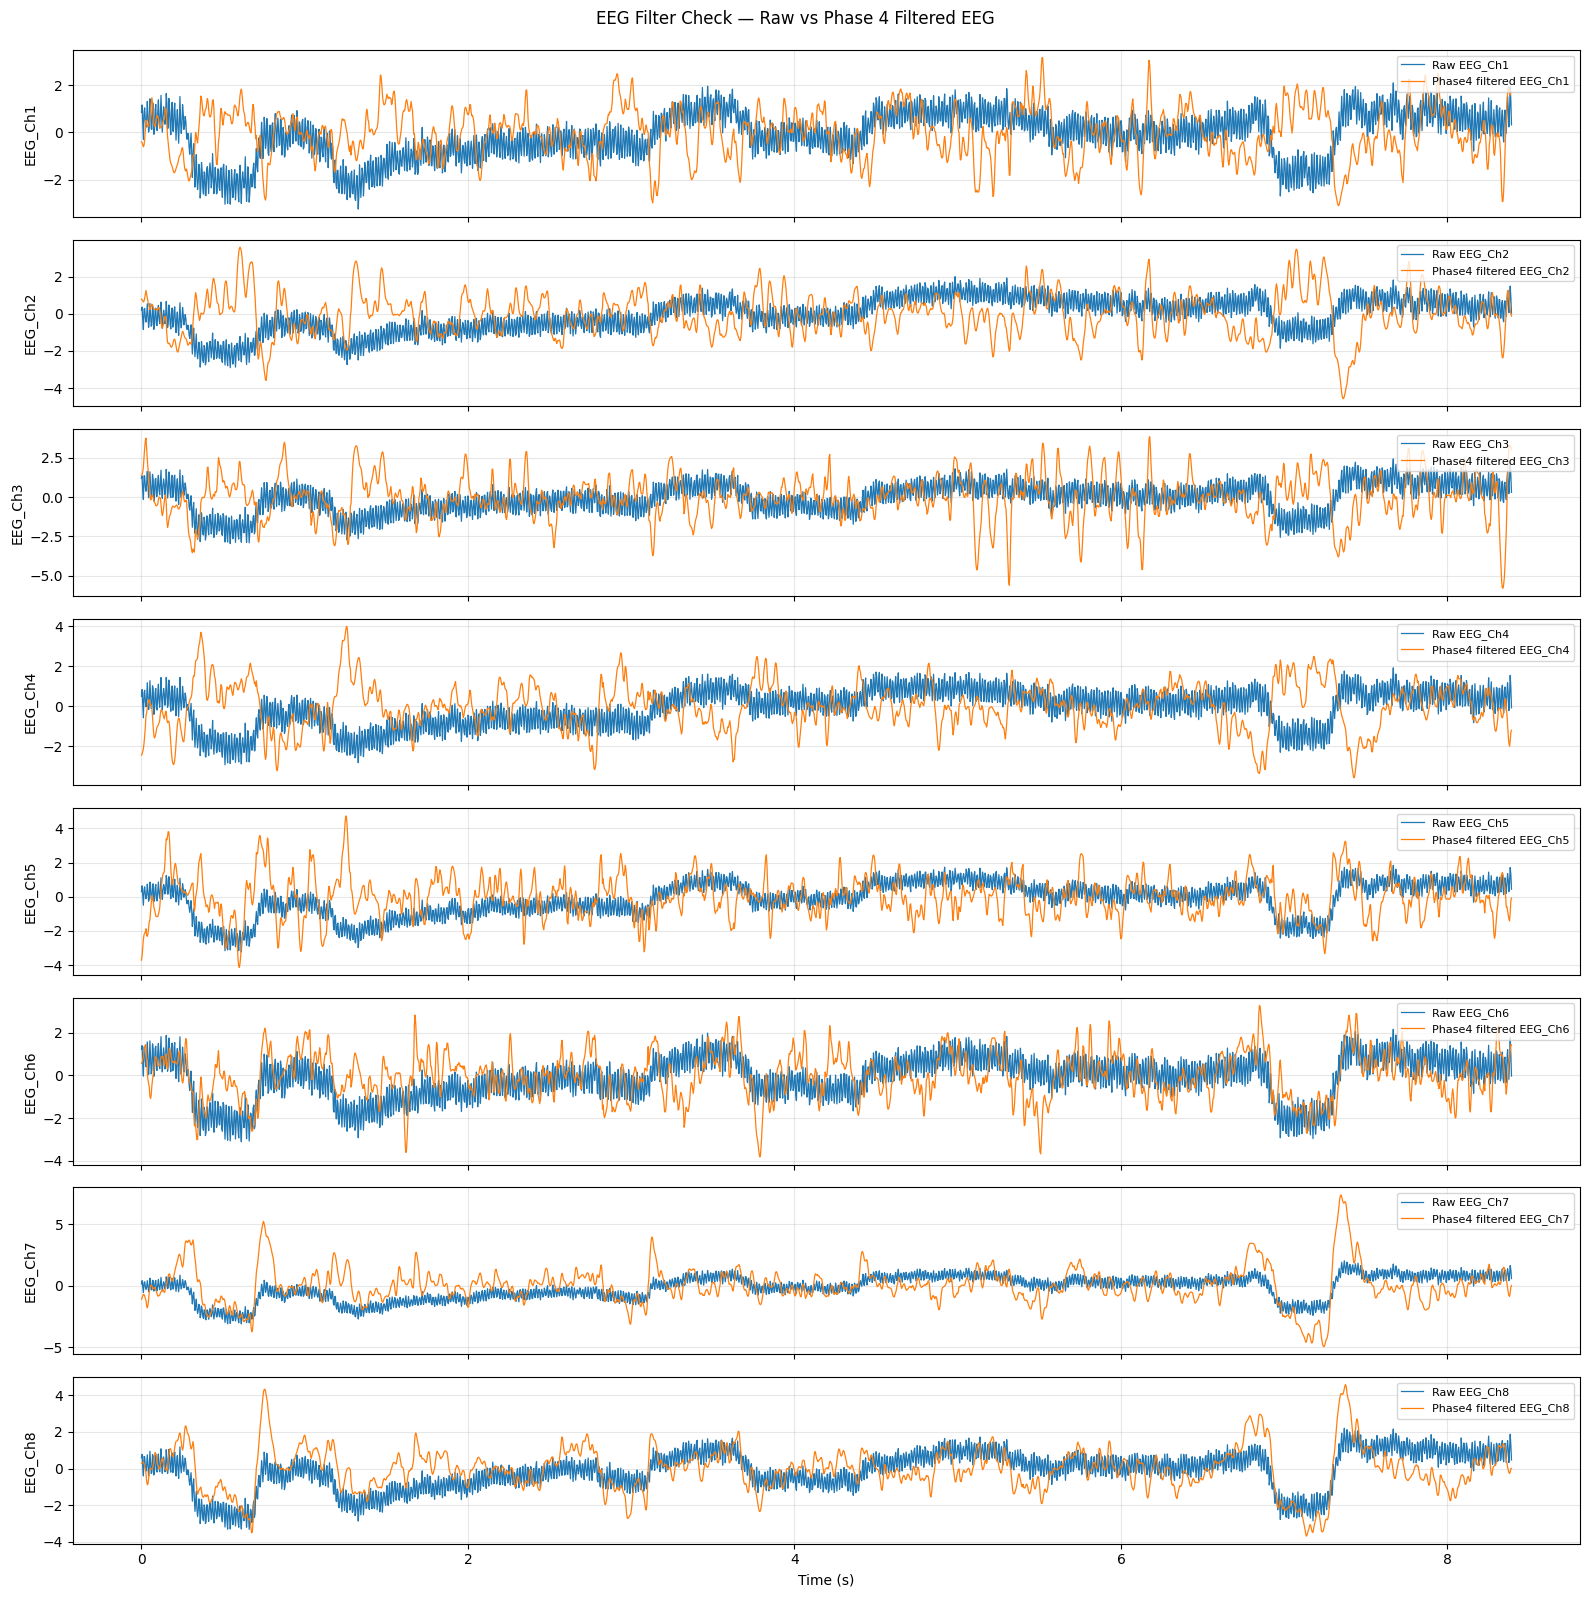

✅ EEG plot completed: raw EEG vs Phase 4 filtered EEG.


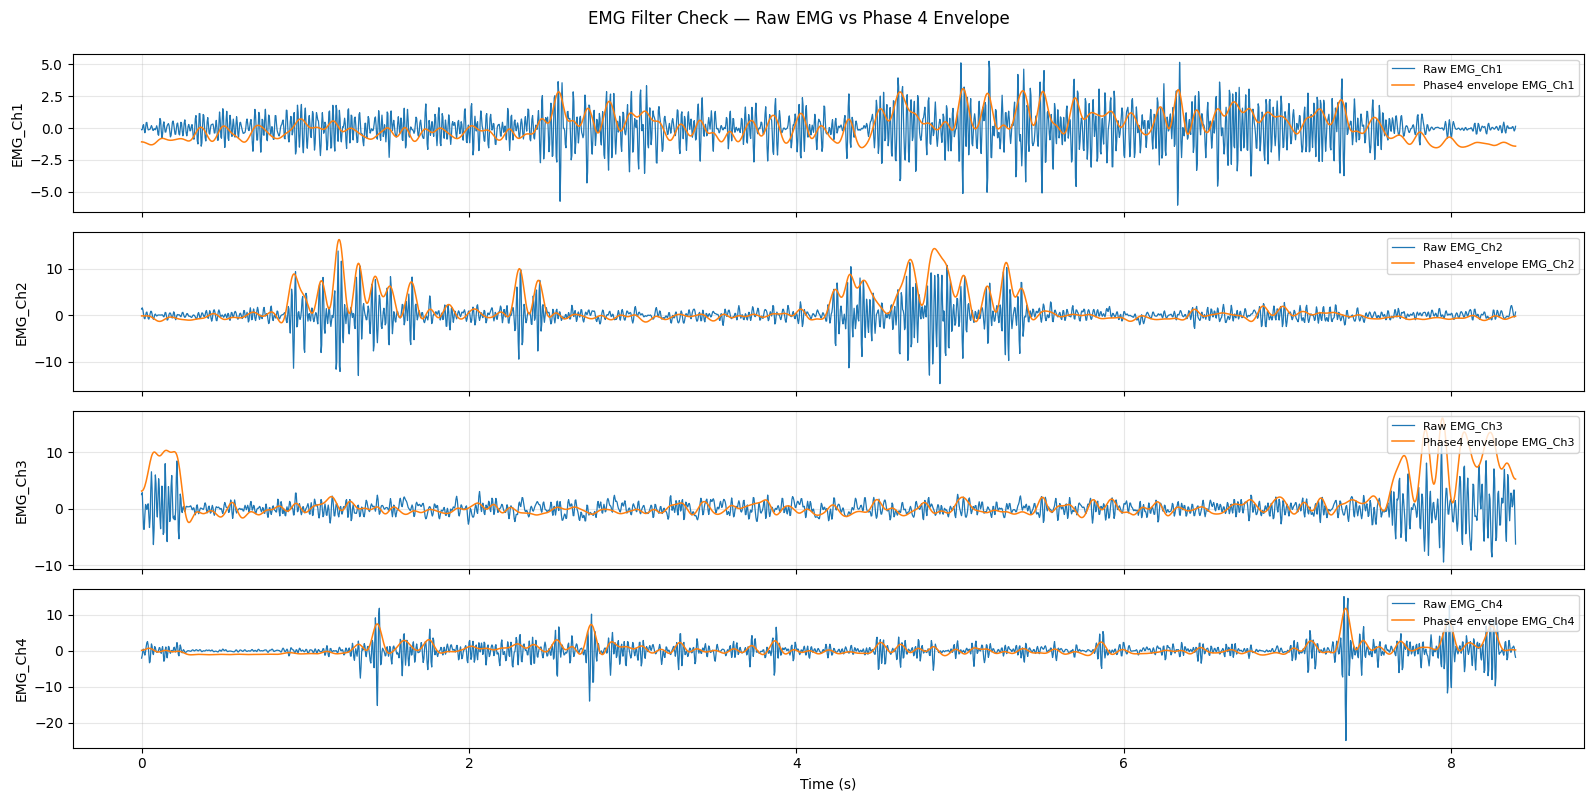

✅ EMG plot completed: raw EMG vs Phase 4 envelope.


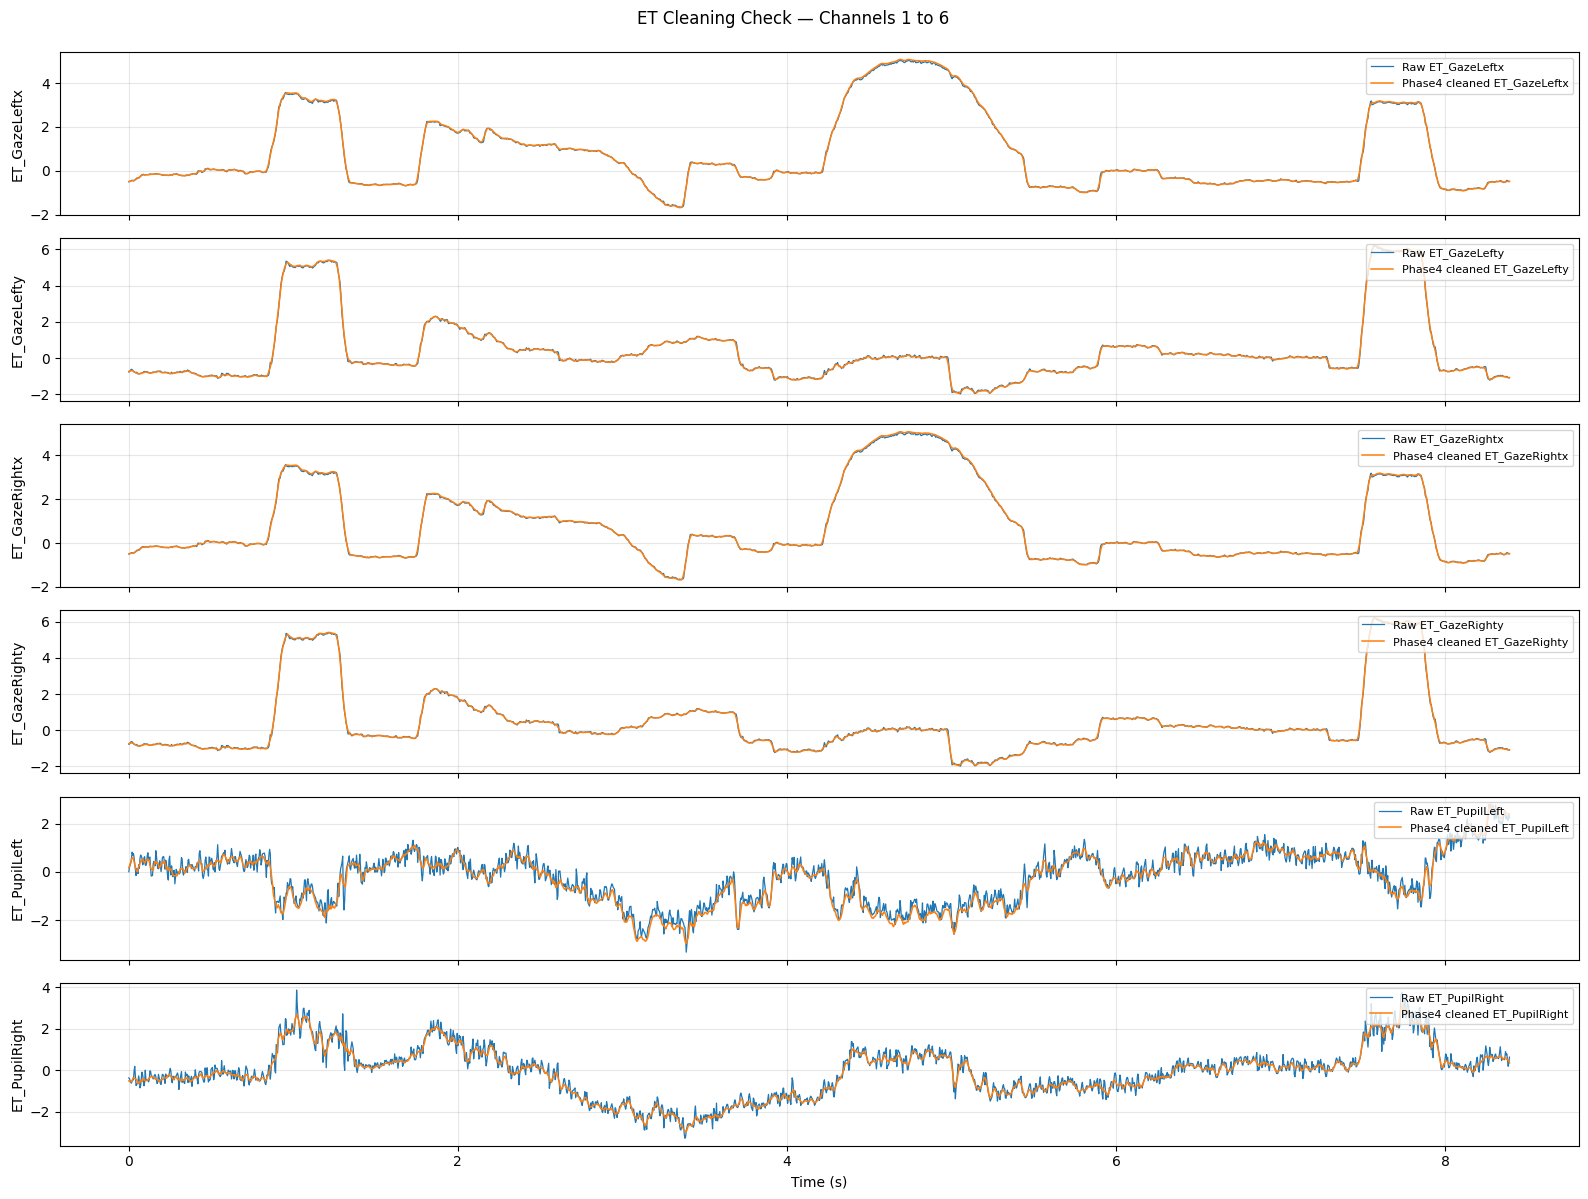

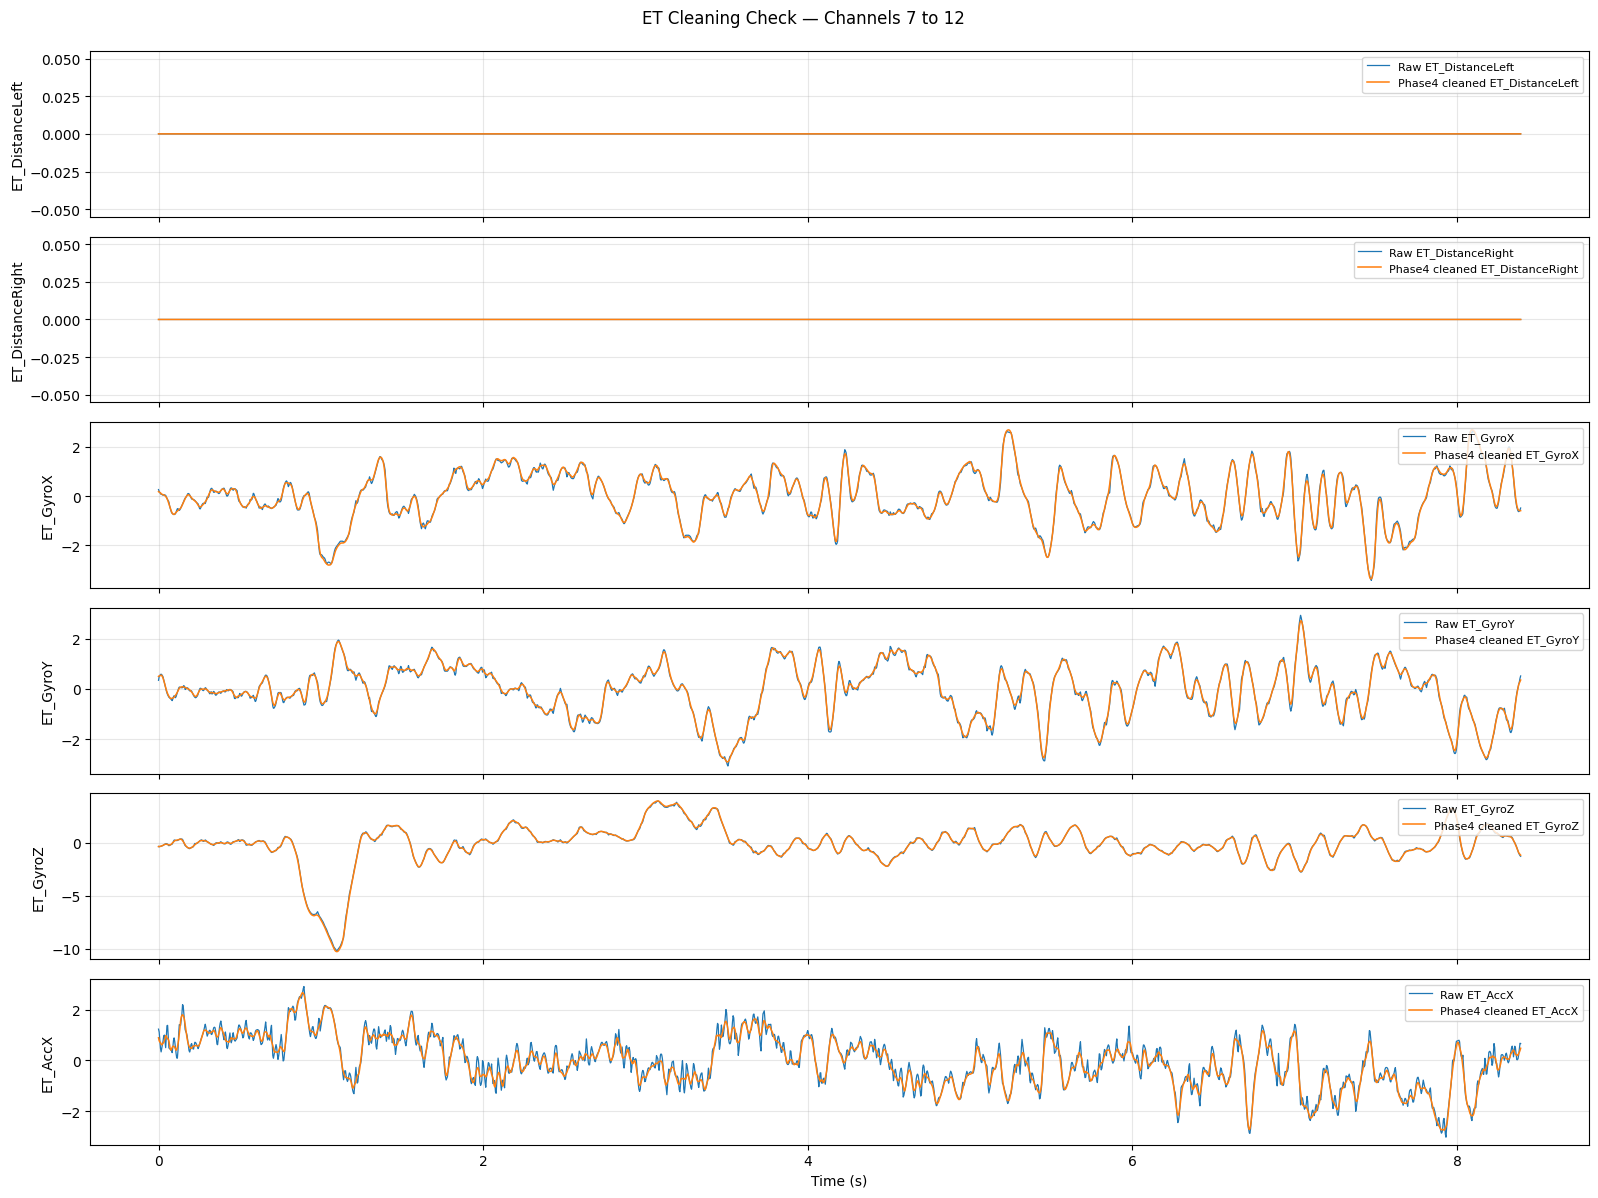

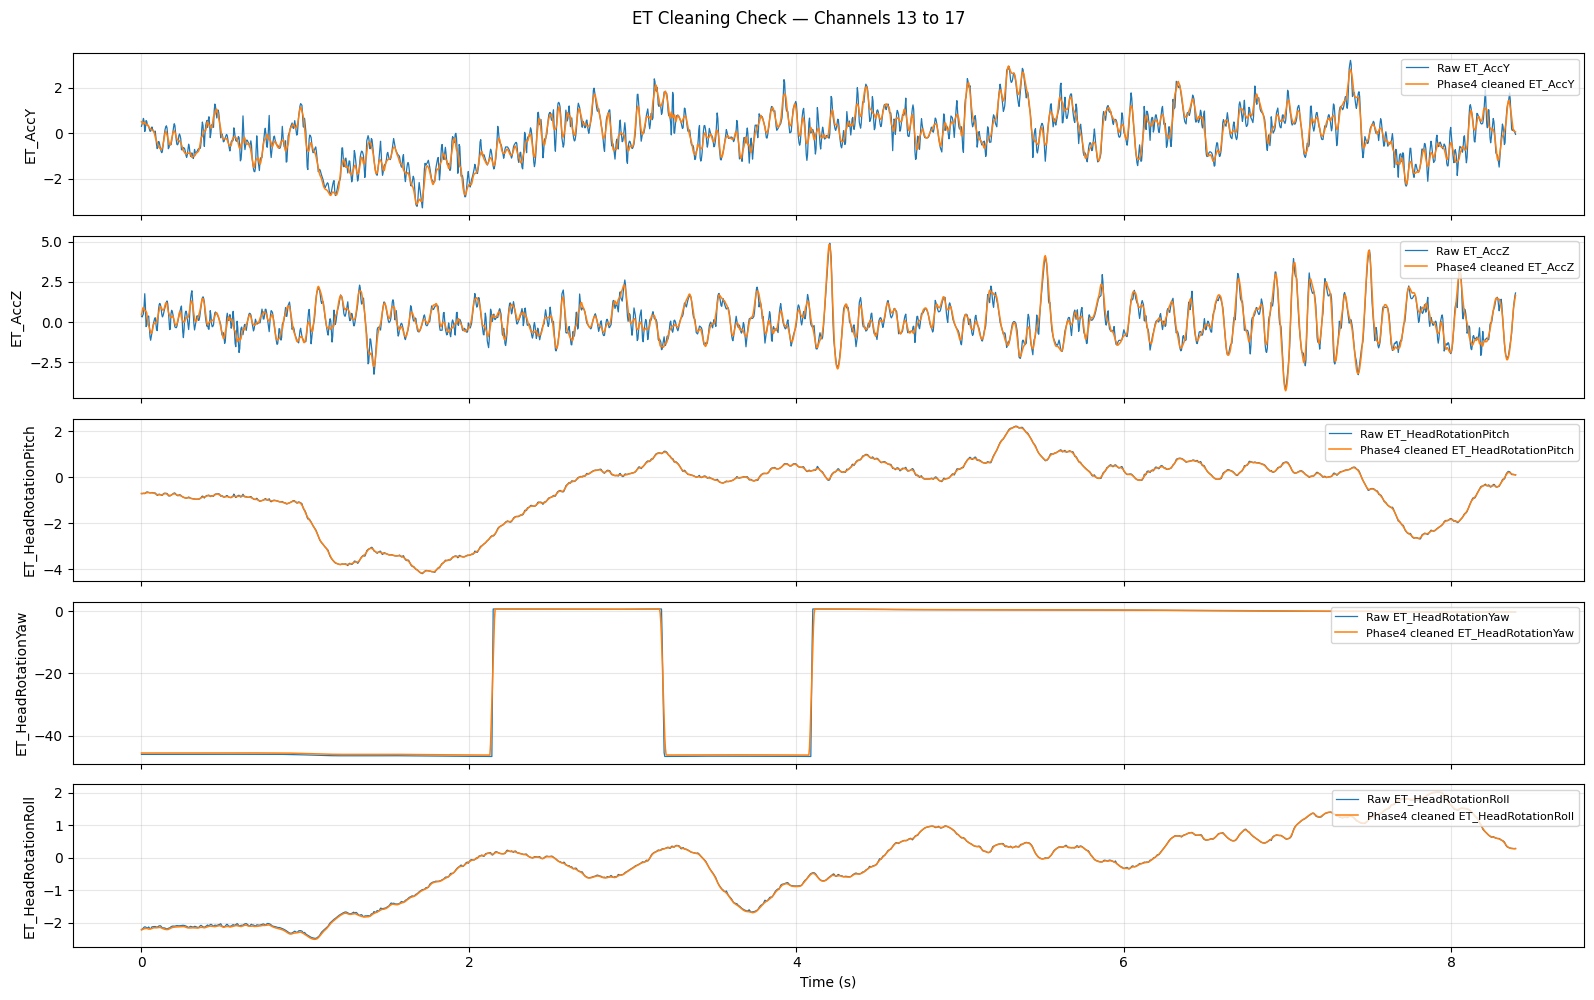

✅ ET plot completed: raw ET vs Phase 4 cleaned ET where available.


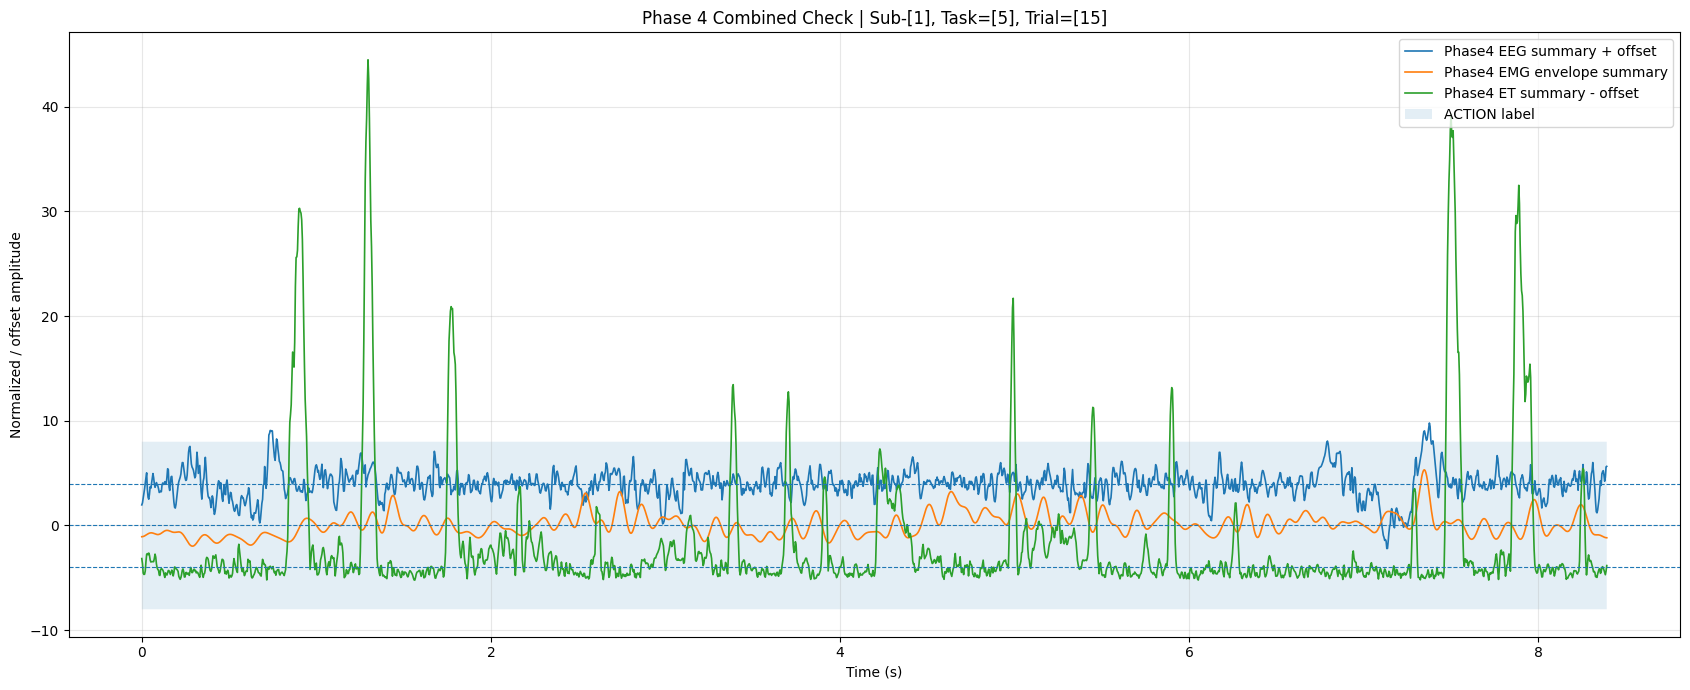


PHASE 4 ONE-TRIAL FILTER CHECK SUMMARY
CSV: /home/tsultan1/BioRob/Human Subject Data/Sub-1/cleaned/synchronized_proper_lite_union_v3/labelonly/003_T515_synchronized_corrected_icml_consensus_labels.csv
NPZ: /home/tsultan1/BioRob/Human Subject Data/Sub-1/cleaned/synchronized_proper_lite_union_v3/labelonly/003_T515_synchronized_corrected_icml_consensus_labels.csv.preproc.npz
Rows: 2099
Estimated fs: 250.0 Hz
EEG channels plotted: 8
EMG channels plotted: 4
ET channels plotted : 17

Expected interpretation:
✅ EEG: filtered signal should be smoother/cleaner than raw but not flat.
✅ EMG: envelope should be positive/smoother and follow activity bursts.
✅ ET: cleaned gaze/pupil/validity streams should be continuous where short gaps were interpolated.
✅ Masks show samples/channels considered lower quality.

✅ ONE-TRIAL PHASE 4 FILTER CHECK COMPLETED.


In [17]:
# ============================================================
# PHASE 4 MANUAL FILTER CHECK — ONE TRIAL ONLY
# This does NOT rerun preprocessing.
# It loads:
#   1) Phase 2B labelonly CSV
#   2) Existing Phase 4 .preproc.npz cache
# and plots raw vs Phase-4 processed EEG, EMG, and ET.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Choose one trial to inspect
# ------------------------------------------------------------
LABELONLY_CSV = Path(
    "/home/tsultan1/BioRob/Human Subject Data/Sub-1/cleaned/"
    "synchronized_proper_lite_union_v3/labelonly/"
    "003_T515_synchronized_corrected_icml_consensus_labels.csv"
)

PREPROC_NPZ = Path(str(LABELONLY_CSV) + ".preproc.npz")

print("=" * 100)
print("LABELONLY CSV:", LABELONLY_CSV)
print("CSV exists   :", LABELONLY_CSV.exists())
print("PREPROC NPZ  :", PREPROC_NPZ)
print("NPZ exists   :", PREPROC_NPZ.exists())
print("=" * 100)

if not LABELONLY_CSV.exists():
    raise FileNotFoundError(f"CSV not found: {LABELONLY_CSV}")

if not PREPROC_NPZ.exists():
    raise FileNotFoundError(
        f"Phase 4 cache not found: {PREPROC_NPZ}\n"
        "Run Phase 4 first for this file, or choose another labelonly CSV."
    )

raw_df = pd.read_csv(LABELONLY_CSV)
cache = np.load(PREPROC_NPZ, allow_pickle=True)

print("\nRaw CSV shape:", raw_df.shape)
print("Phase 4 cache keys:")
for k in cache.files:
    print(" -", k)

# ------------------------------------------------------------
# 2) Metadata/time checks
# ------------------------------------------------------------
required_meta = ["subject_id", "task", "trial", "Timestamp_seconds"]
missing_meta = [c for c in required_meta if c not in raw_df.columns]
if missing_meta:
    raise ValueError(f"Missing metadata columns in CSV: {missing_meta}")

subject_values = raw_df["subject_id"].dropna().unique()
task_values = raw_df["task"].dropna().unique()
trial_values = raw_df["trial"].dropna().unique()

print("\nMetadata from CSV:")
print("subject_id:", subject_values)
print("task      :", task_values)
print("trial     :", trial_values)

t = pd.to_numeric(raw_df["Timestamp_seconds"], errors="coerce").to_numpy(dtype=float)
t = t - np.nanmin(t)

dt = np.diff(t)
fs_est = 1.0 / np.nanmedian(dt)

print("\nTime check:")
print("Duration:", round(float(t[-1] - t[0]), 3), "sec")
print("Median dt:", round(float(np.nanmedian(dt)), 6))
print("Estimated fs:", round(float(fs_est), 2), "Hz")

if abs(fs_est - 250) < 2:
    print("✅ Time grid looks close to 250 Hz.")
else:
    print("⚠️ Time grid is not close to 250 Hz.")

# ------------------------------------------------------------
# 3) Helper functions
# ------------------------------------------------------------
def decode_ch_names(x):
    """Decode channel-name arrays from NPZ safely."""
    out = []
    for v in list(x):
        if isinstance(v, bytes):
            out.append(v.decode("utf-8"))
        else:
            out.append(str(v))
    return out

def robust_z(x):
    """Normalize only for plotting. Does not change data."""
    x = np.asarray(x, dtype=float)

    if np.all(np.isnan(x)):
        return np.zeros_like(x)

    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))

    if mad < 1e-12 or np.isnan(mad):
        std = np.nanstd(x)
        if std < 1e-12 or np.isnan(std):
            return np.zeros_like(x)
        return (x - np.nanmean(x)) / std

    return (x - med) / (1.4826 * mad)

def to_numeric_vector(df, col):
    return pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)

def raw_cols_existing(cols):
    return [c for c in cols if c in raw_df.columns]

def safe_get_cache_array(key):
    if key not in cache.files:
        raise KeyError(f"Missing key in Phase 4 cache: {key}")
    return cache[key]

# ------------------------------------------------------------
# 4) Load Phase 4 processed arrays
# ------------------------------------------------------------
EEG = safe_get_cache_array("EEG")
EMG_env = safe_get_cache_array("EMG_env")
ET = safe_get_cache_array("ET")

EEG_ch = decode_ch_names(safe_get_cache_array("EEG_ch"))
EMG_ch = decode_ch_names(safe_get_cache_array("EMG_ch"))
ET_ch = decode_ch_names(safe_get_cache_array("ET_ch"))

print("\nPhase 4 processed shapes:")
print("EEG     :", EEG.shape, "| channels:", EEG_ch)
print("EMG_env :", EMG_env.shape, "| channels:", EMG_ch)
print("ET      :", ET.shape, "| channels:", ET_ch)

# Optional masks
EEG_mask = cache["EEG_mask"] if "EEG_mask" in cache.files else None
EMG_mask = cache["EMG_mask"] if "EMG_mask" in cache.files else None
ET_mask = cache["ET_mask"] if "ET_mask" in cache.files else None

# Labels if available
label_action = None
if "labels" in cache.files and "label_ch" in cache.files:
    label_ch = decode_ch_names(cache["label_ch"])
    labels = cache["labels"]
    if "label_action" in label_ch:
        idx = label_ch.index("label_action")
        label_action = labels[:, idx]
elif "label_action" in raw_df.columns:
    label_action = pd.to_numeric(raw_df["label_action"], errors="coerce").fillna(0).to_numpy()

# ------------------------------------------------------------
# 5) Detect raw CSV columns
# ------------------------------------------------------------
raw_eeg_cols = raw_cols_existing([f"EEG_Ch{i}" for i in range(1, 9)])
raw_emg_cols = raw_cols_existing([f"EMG_Ch{i}" for i in range(1, 5)])
raw_et_cols = raw_cols_existing(ET_ch)

print("\nRaw CSV detected columns:")
print("Raw EEG:", raw_eeg_cols)
print("Raw EMG:", raw_emg_cols)
print("Raw ET matching Phase 4 ET_ch:", raw_et_cols)

if len(raw_eeg_cols) == 0:
    raise ValueError("No raw EEG columns found in CSV.")
if len(raw_emg_cols) == 0:
    raise ValueError("No raw EMG columns found in CSV.")
if len(raw_et_cols) == 0:
    print("⚠️ No raw ET columns matched ET_ch exactly. ET processed plot will still be shown.")

# ------------------------------------------------------------
# 6) Plot EEG — all channels raw vs Phase 4 filtered
# ------------------------------------------------------------
n_eeg = min(len(raw_eeg_cols), EEG.shape[1])

fig, axes = plt.subplots(n_eeg, 1, figsize=(16, max(8, 2.0 * n_eeg)), sharex=True)

if n_eeg == 1:
    axes = [axes]

for i in range(n_eeg):
    raw_col = raw_eeg_cols[i]
    proc_ch = EEG_ch[i] if i < len(EEG_ch) else f"EEG_{i}"

    raw_sig = to_numeric_vector(raw_df, raw_col)
    proc_sig = EEG[:, i]

    axes[i].plot(t, robust_z(raw_sig), linewidth=0.9, label=f"Raw {raw_col}")
    axes[i].plot(t, robust_z(proc_sig), linewidth=0.9, label=f"Phase4 filtered {proc_ch}")

    if EEG_mask is not None and EEG_mask.ndim == 2 and i < EEG_mask.shape[1]:
        bad = EEG_mask[:, i] < 0.5
        if bad.any():
            axes[i].fill_between(t, -5, 5, where=bad, alpha=0.12, label="EEG mask/bad")

    axes[i].set_ylabel(proc_ch)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("EEG Filter Check — Raw vs Phase 4 Filtered EEG", y=0.995)
plt.tight_layout()
plt.show()

print("✅ EEG plot completed: raw EEG vs Phase 4 filtered EEG.")

# ------------------------------------------------------------
# 7) Plot EMG — all channels raw vs Phase 4 envelope
# ------------------------------------------------------------
n_emg = min(len(raw_emg_cols), EMG_env.shape[1])

fig, axes = plt.subplots(n_emg, 1, figsize=(16, max(7, 2.0 * n_emg)), sharex=True)

if n_emg == 1:
    axes = [axes]

for i in range(n_emg):
    raw_col = raw_emg_cols[i]
    proc_ch = EMG_ch[i] if i < len(EMG_ch) else f"EMG_{i}"

    raw_sig = to_numeric_vector(raw_df, raw_col)
    env_sig = EMG_env[:, i]

    axes[i].plot(t, robust_z(raw_sig), linewidth=0.9, label=f"Raw {raw_col}")
    axes[i].plot(t, robust_z(env_sig), linewidth=1.1, label=f"Phase4 envelope {proc_ch}")

    if EMG_mask is not None and EMG_mask.ndim == 2 and i < EMG_mask.shape[1]:
        bad = EMG_mask[:, i] < 0.5
        if bad.any():
            axes[i].fill_between(t, -5, 5, where=bad, alpha=0.12, label="EMG mask/bad")

    axes[i].set_ylabel(proc_ch)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("EMG Filter Check — Raw EMG vs Phase 4 Envelope", y=0.995)
plt.tight_layout()
plt.show()

print("✅ EMG plot completed: raw EMG vs Phase 4 envelope.")

# ------------------------------------------------------------
# 8) Plot ET — all ET channels in pages
# ------------------------------------------------------------
# Plot all Phase 4 ET channels. If matching raw column exists,
# raw vs processed is shown. Otherwise processed only is shown.
# ------------------------------------------------------------
max_channels_per_fig = 6
n_et = ET.shape[1]

for start in range(0, n_et, max_channels_per_fig):
    end = min(start + max_channels_per_fig, n_et)
    n_page = end - start

    fig, axes = plt.subplots(n_page, 1, figsize=(16, max(7, 2.0 * n_page)), sharex=True)

    if n_page == 1:
        axes = [axes]

    for ax_i, ch_i in enumerate(range(start, end)):
        ch_name = ET_ch[ch_i] if ch_i < len(ET_ch) else f"ET_{ch_i}"
        proc_sig = ET[:, ch_i]

        if ch_name in raw_df.columns:
            raw_sig = to_numeric_vector(raw_df, ch_name)
            ax = axes[ax_i]
            ax.plot(t, robust_z(raw_sig), linewidth=0.9, label=f"Raw {ch_name}")
            ax.plot(t, robust_z(proc_sig), linewidth=1.1, label=f"Phase4 cleaned {ch_name}")
        else:
            ax = axes[ax_i]
            ax.plot(t, robust_z(proc_sig), linewidth=1.1, label=f"Phase4 cleaned {ch_name}")

        if ET_mask is not None and ET_mask.ndim == 2 and ch_i < ET_mask.shape[1]:
            bad = ET_mask[:, ch_i] < 0.5
            if bad.any():
                ax.fill_between(t, -5, 5, where=bad, alpha=0.12, label="ET mask/bad")

        ax.set_ylabel(ch_name)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right", fontsize=8)

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"ET Cleaning Check — Channels {start+1} to {end}", y=0.995)
    plt.tight_layout()
    plt.show()

print("✅ ET plot completed: raw ET vs Phase 4 cleaned ET where available.")

# ------------------------------------------------------------
# 9) Combined summary plot — EEG + EMG + ET + action label
# ------------------------------------------------------------
eeg_summary = np.nanmean(EEG, axis=1)
emg_summary = np.nanmean(EMG_env, axis=1)

# ET gaze speed if gaze columns exist in Phase 4 ET_ch
et_summary = None
if "ET_GazeLeftx" in ET_ch and "ET_GazeLefty" in ET_ch:
    gx = ET[:, ET_ch.index("ET_GazeLeftx")]
    gy = ET[:, ET_ch.index("ET_GazeLefty")]
    et_summary = np.sqrt(np.gradient(gx) ** 2 + np.gradient(gy) ** 2)
elif "ET_GazeRightx" in ET_ch and "ET_GazeRighty" in ET_ch:
    gx = ET[:, ET_ch.index("ET_GazeRightx")]
    gy = ET[:, ET_ch.index("ET_GazeRighty")]
    et_summary = np.sqrt(np.gradient(gx) ** 2 + np.gradient(gy) ** 2)
else:
    et_summary = np.nanmean(ET, axis=1)

plt.figure(figsize=(17, 7))

plt.plot(t, robust_z(eeg_summary) + 4, linewidth=1.2, label="Phase4 EEG summary + offset")
plt.plot(t, robust_z(emg_summary), linewidth=1.2, label="Phase4 EMG envelope summary")
plt.plot(t, robust_z(et_summary) - 4, linewidth=1.2, label="Phase4 ET summary - offset")

if label_action is not None:
    action = np.asarray(label_action).astype(float)
    action = (action >= 0.5)
    plt.fill_between(t, -8, 8, where=action, alpha=0.12, label="ACTION label")

plt.axhline(4, linestyle="--", linewidth=0.8)
plt.axhline(0, linestyle="--", linewidth=0.8)
plt.axhline(-4, linestyle="--", linewidth=0.8)

plt.xlabel("Time (s)")
plt.ylabel("Normalized / offset amplitude")
plt.title(
    f"Phase 4 Combined Check | "
    f"Sub-{subject_values}, Task={task_values}, Trial={trial_values}"
)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10) Final print summary
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("PHASE 4 ONE-TRIAL FILTER CHECK SUMMARY")
print("=" * 100)

print("CSV:", LABELONLY_CSV)
print("NPZ:", PREPROC_NPZ)
print("Rows:", len(raw_df))
print("Estimated fs:", round(float(fs_est), 2), "Hz")
print("EEG channels plotted:", n_eeg)
print("EMG channels plotted:", n_emg)
print("ET channels plotted :", n_et)

print("\nExpected interpretation:")
print("✅ EEG: filtered signal should be smoother/cleaner than raw but not flat.")
print("✅ EMG: envelope should be positive/smoother and follow activity bursts.")
print("✅ ET: cleaned gaze/pupil/validity streams should be continuous where short gaps were interpolated.")
print("✅ Masks show samples/channels considered lower quality.")
print("\n✅ ONE-TRIAL PHASE 4 FILTER CHECK COMPLETED.")